# World Cup 2026 Match Prediction Model

This notebook builds a clean, match-level training table from multiple historical datasets, performs feature engineering and trains classification and score prediction models for international football matches. It adheres strictly to the rule that all features joined to a match must be known prior to kickoff.

## 1. Import Libraries and Load Datasets

In [78]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, mean_absolute_error

Imports for data cleaning and EDA for a Baseline Logistic Regression

In [79]:
import os
import warnings

import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.metrics import accuracy_score, log_loss, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 300)


### This is the datasets that I prepared for training

In [80]:
# Path
datasets_dir = "/Users/raresolteanu/Desktop/WC-2026/datasets"

# Load files
df_res = pd.read_csv(os.path.join(datasets_dir, "Historical international match results.csv"))
df_elo = pd.read_csv(os.path.join(datasets_dir, "Elo ratings.csv"))
df_fifa = pd.read_csv(os.path.join(datasets_dir, "FIFA rankings.csv"))
df_form = pd.read_csv(os.path.join(datasets_dir, "Recent form.csv"))
df_goals = pd.read_csv(os.path.join(datasets_dir, "Goals scored conceded.csv"))
df_home = pd.read_csv(os.path.join(datasets_dir, "Home region advantage.csv"))
df_rest = pd.read_csv(os.path.join(datasets_dir, "Rest days.csv"))
df_stage = pd.read_csv(os.path.join(datasets_dir, "Tournament stage.csv"))

print(f"Results: {len(df_res)} rows")
print(f"Elo ratings: {len(df_elo)} rows")
print(f"FIFA rankings: {len(df_fifa)} rows")
print(f"Recent form: {len(df_form)} rows")
print(f"Goals scored/conceded: {len(df_goals)} rows")

Results: 49403 rows
Elo ratings: 98810 rows
FIFA rankings: 67931 rows
Recent form: 98810 rows
Goals scored/conceded: 98810 rows


In [82]:
print(f'The shape of Historical international match results {df_res.shape}')
print(f'The shape of Elo ratings {df_elo.shape}')
print(f'The shape of FIFA rankings {df_fifa.shape}')
print(f'The shape of Recent form {df_form.shape}')
print(f'The shape of Goals scored conceded {df_goals.shape}')
print(f'The shape of Home region advantage {df_home.shape}')
print(f'The shape of Rest days {df_rest.shape}')
print(f'The shape of Tournament stage {df_stage.shape}')


The shape of Historical international match results (49403, 9)
The shape of Elo ratings (98810, 7)
The shape of FIFA rankings (67931, 5)
The shape of Recent form (98810, 20)
The shape of Goals scored conceded (98810, 9)
The shape of Home region advantage (49475, 12)
The shape of Rest days (49475, 7)
The shape of Tournament stage (1036, 5)


In [83]:
df_res.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [84]:
df_elo.head()

,date,team,elo_rating,opponent,goals_for,goals_against,is_home
0,1872-11-30,Scotland,1500.000000,England,0,0,True
1,1872-11-30,England,1500.000000,Scotland,0,0,False
2,1873-03-08,England,1502.801300,Scotland,4,2,True
3,1873-03-08,Scotland,1497.198700,England,2,4,False
4,1874-03-07,Scotland,1486.622531,England,2,1,True


In [85]:
df_fifa.head()

,date,team,total_points,rank,team_short
0,1992-12-31,Germany,57.0,1,GER
1,1992-12-31,Italy,57.0,1,ITA
2,1992-12-31,Brazil,56.0,3,BRA
3,1992-12-31,Sweden,56.0,3,SWE
4,1992-12-31,England,55.0,5,ENG


In [86]:
df_form.head()

,date,team,opponent,is_home,matches_5,wins_5,draws_5,losses_5,goals_scored_5,goals_conceded_5,points_5,form_score_5,matches_10,wins_10,draws_10,losses_10,goals_scored_10,goals_conceded_10,points_10,form_score_10
0,1872-11-30,Scotland,England,True,0,0,0,0,0,0,0,0.000,0,0,0,0,0,0,0,0.000
1,1872-11-30,England,Scotland,False,0,0,0,0,0,0,0,0.000,0,0,0,0,0,0,0,0.000
2,1873-03-08,England,Scotland,True,1,0,1,0,0,0,1,0.333,1,0,1,0,0,0,1,0.333
3,1873-03-08,Scotland,England,False,1,0,1,0,0,0,1,0.333,1,0,1,0,0,0,1,0.333
4,1874-03-07,Scotland,England,True,2,0,1,1,2,4,1,0.167,2,0,1,1,2,4,1,0.167


In [87]:
df_goals.head()

,date,team,opponent,is_home,cumulative_matches,cumulative_goals_scored,cumulative_goals_conceded,average_goals_scored,average_goals_conceded
0,1872-11-30,Scotland,England,True,0,0,0,0.0,0.0
1,1872-11-30,England,Scotland,False,0,0,0,0.0,0.0
2,1873-03-08,England,Scotland,True,1,0,0,0.0,0.0
3,1873-03-08,Scotland,England,False,1,0,0,0.0,0.0
4,1874-03-07,Scotland,England,True,2,2,4,1.0,2.0


In [88]:
df_home.head()

,date,home_team,away_team,country,neutral,home_confederation,away_confederation,host_confederation,is_home_country,is_away_country,is_home_confed,is_away_confed
0,1872-11-30,Scotland,England,Scotland,False,UEFA,UEFA,UEFA,True,False,True,True
1,1873-03-08,England,Scotland,England,False,UEFA,UEFA,UEFA,True,False,True,True
2,1874-03-07,Scotland,England,Scotland,False,UEFA,UEFA,UEFA,True,False,True,True
3,1875-03-06,England,Scotland,England,False,UEFA,UEFA,UEFA,True,False,True,True
4,1876-03-04,Scotland,England,Scotland,False,UEFA,UEFA,UEFA,True,False,True,True


In [89]:
df_rest.head()

,date,home_team,away_team,home_rest_days,away_rest_days,home_rest_days_capped,away_rest_days_capped
0,1872-11-30,Scotland,England,7.0,7.0,7.0,7.0
1,1873-03-08,England,Scotland,98.0,98.0,10.0,10.0
2,1874-03-07,Scotland,England,364.0,364.0,10.0,10.0
3,1875-03-06,England,Scotland,364.0,364.0,10.0,10.0
4,1876-03-04,Scotland,England,364.0,364.0,10.0,10.0


In [90]:
df_stage.head()

,date,home_team,away_team,world_cup_year,stage
0,1930-07-13,Belgium,United States,1930,Group Stage
1,1930-07-13,France,Mexico,1930,Group Stage
2,1930-07-14,Brazil,Yugoslavia,1930,Group Stage
3,1930-07-14,Peru,Romania,1930,Group Stage
4,1930-07-15,Argentina,France,1930,Group Stage


In [91]:
print("=== HISTORICAL RESULTS NULL COUNTS ===")
display(df_res.isna().sum())
print("\n=== ELO RATINGS NULL COUNTS ===")
display(df_elo.isna().sum())
print("\n=== FIFA RANKINGS NULL COUNTS ===")
display(df_fifa.isna().sum())
print("\n=== RECENT FORM NULL COUNTS ===")
display(df_form.isna().sum())
print("\n=== GOALS SCORED/CONCEDED NULL COUNTS ===")
display(df_goals.isna().sum())
print("\n=== HOME REGION ADVANTAGE NULL COUNTS ===")
display(df_home.isna().sum())
print("\n=== REST DAYS NULL COUNTS ===")
display(df_rest.isna().sum())
print("\n=== TOURNAMENT STAGE NULL COUNTS ===")
display(df_stage.isna().sum())

=== HISTORICAL RESULTS NULL COUNTS ===


date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64


=== ELO RATINGS NULL COUNTS ===


date             0
team             0
elo_rating       0
opponent         0
goals_for        0
goals_against    0
is_home          0
dtype: int64


=== FIFA RANKINGS NULL COUNTS ===


...

date                  0
home_team             0
away_team             0
country               0
neutral               0
home_confederation    0
away_confederation    0
host_confederation    0
is_home_country       0
is_away_country       0
is_home_confed        0
is_away_confed        0
dtype: int64


=== REST DAYS NULL COUNTS ===


date                     0
home_team                0
away_team                0
home_rest_days           0
away_rest_days           0
home_rest_days_capped    0
away_rest_days_capped    0
dtype: int64


=== TOURNAMENT STAGE NULL COUNTS ===


date              0
home_team         0
away_team         0
world_cup_year    0
stage             0
dtype: int64

### There are no missing values

### Check for duplicate rows

In [92]:
for name, df in {'df_res': df_res, 'df_elo': df_elo, 'df_fifa': df_fifa, 'df_form': df_form, 'df_goals': df_goals, 'df_home': df_home, 'df_rest': df_rest, 'df_stage': df_stage}.items():
    print(f"{name} duplicates:", df.duplicated().sum())

df_res duplicates: 0
df_elo duplicates: 0
df_fifa duplicates: 0
df_form duplicates: 0
df_goals duplicates: 0
df_home duplicates: 0
df_rest duplicates: 0
df_stage duplicates: 0


In [93]:
for name, df in {'df_res': df_res, 'df_elo': df_elo, 'df_fifa': df_fifa, 'df_form': df_form, 'df_goals': df_goals, 'df_home': df_home, 'df_rest': df_rest, 'df_stage': df_stage}.items():
    print(f"{name} Match Results Date Range:", df['date'].min(), 'to', df['date'].max())

df_res Match Results Date Range: 1872-11-30 to 2026-06-10
df_elo Match Results Date Range: 1872-11-30 to 2026-06-10
df_fifa Match Results Date Range: 1992-12-31 to 2026-06-11
df_form Match Results Date Range: 1872-11-30 to 2026-06-10
df_goals Match Results Date Range: 1872-11-30 to 2026-06-10
df_home Match Results Date Range: 1872-11-30 to 2026-06-27
df_rest Match Results Date Range: 1872-11-30 to 2026-06-27
df_stage Match Results Date Range: 1930-07-13 to 2026-06-27


### based on this we can see that the range of data is different and we have to options to solve it filling it or filtering it *date >= '1993-01-01'*

### we thought to filter it because:
* Football has changed drastically: Matches from 1880 or 1950 were played under different rules, tactics, and levels of professionalism.
* Quality over quantity: Imputing 120 years of missing FIFA rankings with a default value (like rank 215) dilutes the ranking feature and makes it less predictive.

# Filter for matches played on or after January 1, 1993

In [94]:
TEAM_NAME_MAP = {
    "Aotearoa New Zealand": "New Zealand",
    "Cape Verde Islands": "Cape Verde",
    "China PR": "China",
    "Chinese Taipei": "Taiwan",
    "Korea Republic": "South Korea",
    "IR Iran": "Iran",
    "USA": "United States",
    "Côte d'Ivoire": "Ivory Coast",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Brunei Darussalam": "Brunei",
    "Korea DPR": "North Korea",
    "Curacao": "Curaçao",
    "Hong Kong, China": "Hong Kong",
    "Sao Tome e Principe": "São Tomé and Príncipe",
    "São Tomé e Príncipe": "São Tomé and Príncipe",
    "The Gambia": "Gambia",
    "St Kitts and Nevis": "Saint Kitts and Nevis",
    "St. Kitts and Nevis": "Saint Kitts and Nevis",
    "St Lucia": "Saint Lucia",
    "St. Lucia": "Saint Lucia",
    "St Vincent and the Grenadines": "Saint Vincent and the Grenadines",
    "St. Vincent and the Grenadines": "Saint Vincent and the Grenadines",
    "St. Vincent / Grenadines": "Saint Vincent and the Grenadines",
    "US Virgin Islands": "United States Virgin Islands",
    "FYR Macedonia": "North Macedonia",
    "Swaziland": "Eswatini",
    "Zaire": "DR Congo",
}

# These FIFA ranking rows are defunct historical teams that do not have a clean modern one-team mapping.
DEFUNCT_FIFA_TEAMS = {
    "Netherlands Antilles",
    "Serbia and Montenegro",
    "Yugoslavia",
}


The DEFUNCT_FIFA_TEAMS are not simple one-to-one mappings:
* Yugoslavia
* Serbia and Montenegro
* Netherlands Antilles


I would not map these blindly.
Why:
* Yugoslavia is historically different from modern Serbia, Croatia, Bosnia, Slovenia, etc.
* Serbia and Montenegro later split into Serbia and Montenegro.
* Netherlands Antilles dissolved; Curaçao is related but not exactly identical historically.

In [95]:
def normalize_team_name(name):
    if pd.isna(name):
        return name

    name = str(name).strip()
    return TEAM_NAME_MAP.get(name, name)

In [96]:
def normalize_team_columns(df):
    df = df.copy()

    for col in ["team", "home_team", "away_team", "opponent"]:
        if col in df.columns:
            df[col] = df[col].apply(normalize_team_name)

    return df

In [97]:
datasets = {
    "res": df_res,
    "elo": df_elo,
    "fifa": df_fifa,
    "form": df_form,
    "goals": df_goals,
    "home": df_home,
    "rest": df_rest,
    "stage": df_stage,
}

In [98]:
# Convert dates, normalize team names, and keep the modern era used for training.
datasets = {
    name: normalize_team_columns(
        df.assign(date=pd.to_datetime(df["date"], errors="coerce"))
          .query("date >= '1993-01-01'")
          .copy()
    )
    for name, df in datasets.items()
}

# Drop defunct FIFA-only teams that cannot be mapped cleanly to one modern national team.
datasets["fifa"] = datasets["fifa"][~datasets["fifa"]["team"].isin(DEFUNCT_FIFA_TEAMS)].copy()

# Assign the cleaned datasets back to the variables used below.
df_res = datasets["res"]
df_elo = datasets["elo"]
df_fifa = datasets["fifa"]
df_form = datasets["form"]
df_goals = datasets["goals"]
df_home = datasets["home"]
df_rest = datasets["rest"]
df_stage = datasets["stage"]

for name, df in datasets.items():
    print(
        f"{name} range: "
        f"{df['date'].min().strftime('%Y-%m-%d')} "
        f"to {df['date'].max().strftime('%Y-%m-%d')}"
    )


res range: 1993-01-01 to 2026-06-10
elo range: 1993-01-01 to 2026-06-10
fifa range: 1993-08-08 to 2026-06-11
form range: 1993-01-01 to 2026-06-10
goals range: 1993-01-01 to 2026-06-10
home range: 1993-01-01 to 2026-06-27
rest range: 1993-01-01 to 2026-06-27
stage range: 1994-06-17 to 2026-06-27


### *df_fifa* starts on *1993-08-08*:
FIFA only publishes rankings on specific dates. In 1993, the very first rankings update was published on August 8, 1993 (the previous one was December 31, 1992).

### *df_stage* starts on *1994-06-17*:
This dataset only tracks World Cup tournament matches. There was no World Cup tournament in 1993. The next World Cup (USA 1994) kicked off on June 17, 1994.

# Team name compatibility across every dataset


In [100]:
def get_teams(df):
    teams = set()

    if "team" in df.columns:
        teams |= set(df["team"].dropna())

    if "home_team" in df.columns:
        teams |= set(df["home_team"].dropna())

    if "away_team" in df.columns:
        teams |= set(df["away_team"].dropna())

    if "opponent" in df.columns:
        teams |= set(df["opponent"].dropna())

    return teams


def check_team_compatibility(reference_df, datasets):
    reference_teams = get_teams(reference_df)
    rows = []

    for name, df in datasets.items():
        teams = get_teams(df)
        missing_from_dataset = reference_teams - teams
        extra_in_dataset = teams - reference_teams

        rows.append({
            "dataset": name,
            "reference_teams": len(reference_teams),
            "dataset_teams": len(teams),
            "missing_from_dataset": len(missing_from_dataset),
            "extra_in_dataset": len(extra_in_dataset),
            "missing_sample": sorted(missing_from_dataset)[:10],
            "extra_sample": sorted(extra_in_dataset)[:10],
        })

    return pd.DataFrame(rows)


team_feature_report = check_team_compatibility(
    df_res,
    {
        "elo": df_elo,
        "fifa": df_fifa,
        "form": df_form,
        "goals": df_goals,
        "home": df_home,
        "rest": df_rest,
    },
)

# Stage only exists for World Cup matches, so compare it only against World Cup results.
world_cup_results = df_res[df_res["tournament"].eq("FIFA World Cup")].copy()
stage_report = check_team_compatibility(
    world_cup_results,
    {"stage": df_stage},
)

print("Team-level / match-level feature coverage against all historical results")
display(team_feature_report)

print("Tournament stage coverage against World Cup matches only")
display(stage_report)


Team-level / match-level feature coverage against all historical results


,dataset,reference_teams,dataset_teams,missing_from_dataset,extra_in_dataset,missing_sample,extra_sample
0,elo,324,324,0,0,[],[]
1,fifa,324,212,112,0,"[Abkhazia, Alderney, Ambazonia, Andalusia, Ara...",[]
2,form,324,324,0,0,[],[]
3,goals,324,324,0,0,[],[]
4,home,324,324,0,0,[],[]
5,rest,324,324,0,0,[],[]


Tournament stage coverage against World Cup matches only


,dataset,reference_teams,dataset_teams,missing_from_dataset,extra_in_dataset,missing_sample,extra_sample
0,stage,68,75,0,7,[],"[Cape Verde, Curaçao, DR Congo, Haiti, Iraq, J..."


# FIFA rankings do not cover non-FIFA teams in historical results.
# Stage only applies to World Cup matches and extra teams may be future WC 2026 teams.

The 7 extra teams in *df_stage*
* Cape Verde
* Curaçao
* DR Congo
* Haiti
* Iraq
* Jordan
* Uzbekistan

3. Target Distribution Check (Class Balance)

Why: Check how many home wins, draws and away wins exist in history (class balance is important for classifier models).

In [101]:
df_res["result"] = np.select(
    [
        df_res["home_score"] > df_res["away_score"],
        df_res["home_score"] < df_res["away_score"],
    ],
    [
        "home_win",
        "away_win",
    ],
    default="draw",
)

result_distribution = (
    df_res["result"]
    .value_counts()
    .rename_axis("result")
    .reset_index(name="count")
)

result_distribution["percentage"] = (
    result_distribution["count"] / result_distribution["count"].sum() * 100
).round(2)

display(result_distribution)

,result,count,percentage
0,home_win,14905,48.56
1,away_win,8634,28.13
2,draw,7157,23.32


Why this matters:

* If home_win is much larger than the others, the model may overpredict home wins.
* Draws are usually harder to predict.
* You should compare your model against a simple baseline like “always predict home_win”.
* For football, we should use log_loss and probability calibration, not just accuracy.

In [108]:
pip install matplotlib

  Using cached contourpy-1.3.2-cp310-cp310-macosx_10_9_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-macosx_10_9_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp310-cp310-macosx_10_10_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 22.0 MB/s  0:00:00 eta 0:00:01
Using cached contourpy-1.3.2-cp310-cp310-macosx_10_9_x86_64.whl (268 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.3 MB/s  0:00:00
Using cached kiwisolver-1.5.0-cp310-cp310-macosx_10_9_x86_64.whl (66 kB)
Using cached pillow-12.2.0-cp310-cp310-macosx_10_10_x86_64.whl (5.4 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated p

In [109]:
import matplotlib.pyplot as plt

In [127]:
def plot_goal_counts(df, column, title=None):
    counts = df[column].value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar", edgecolor="black")
    plt.title(title or f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

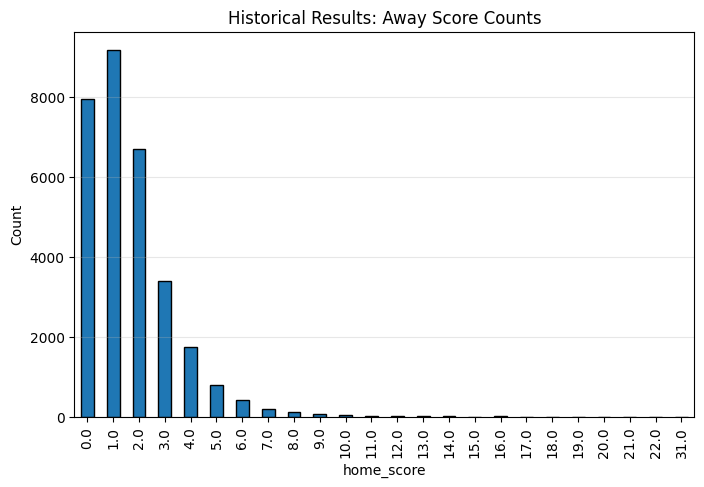

In [129]:
plot_goal_counts(
    df_res,
    "home_score",
    title="Historical Results: Away Score Counts"
)

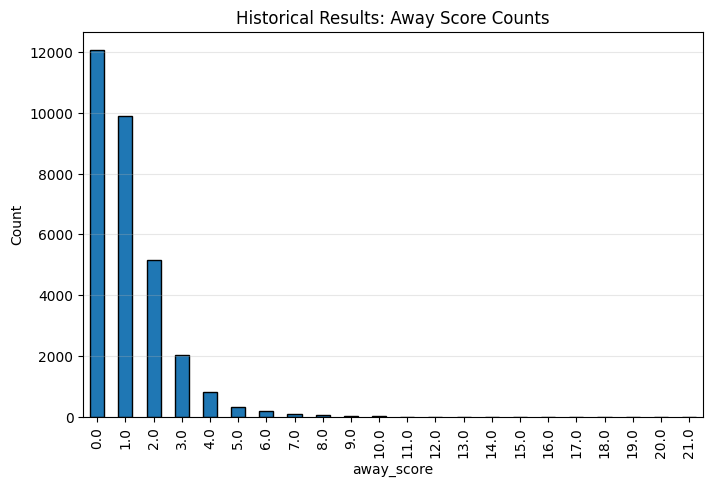

In [128]:
plot_goal_counts(
    df_res,
    "away_score",
    title="Historical Results: Away Score Counts"
)

In [131]:
df_res["home_score"].value_counts().sort_index()

home_score
0.0     7944
1.0     9166
2.0     6699
3.0     3404
4.0     1745
5.0      799
6.0      407
7.0      204
8.0      120
9.0       73
10.0      43
11.0      27
12.0      20
13.0      10
14.0       9
15.0       5
16.0       6
17.0       4
18.0       1
19.0       3
20.0       2
21.0       2
22.0       2
31.0       1
Name: count, dtype: int64

In [132]:
df_res["away_score"].value_counts().sort_index()

away_score
0.0     12063
1.0      9900
2.0      5163
3.0      2035
4.0       825
5.0       319
6.0       177
7.0       101
8.0        45
9.0        19
10.0       18
11.0        5
12.0        6
13.0        3
14.0        1
15.0        4
16.0        2
17.0        3
18.0        3
19.0        1
20.0        2
21.0        1
Name: count, dtype: int64

In [125]:
def plot_all_numeric_hists(df, dataset_name="Dataset", bins=30):
    numeric_cols = df.select_dtypes(include=["number"]).columns

    for col in numeric_cols:
        plot_hist(
            df,
            col,
            title=f"{dataset_name}: Distribution of {col}",
            xlabel=col,
            bins=bins
        )

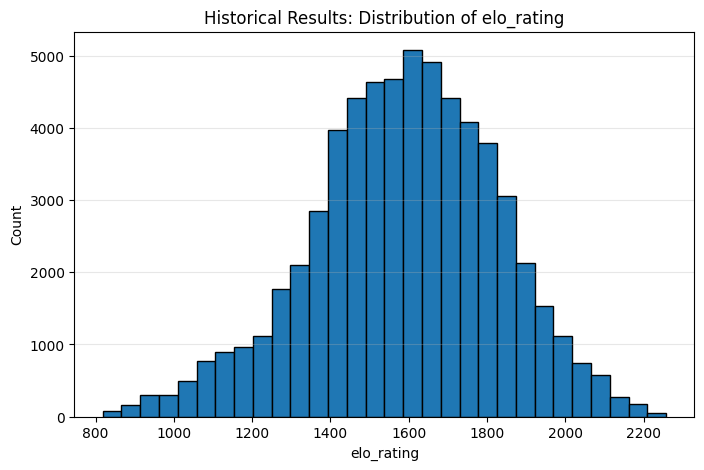

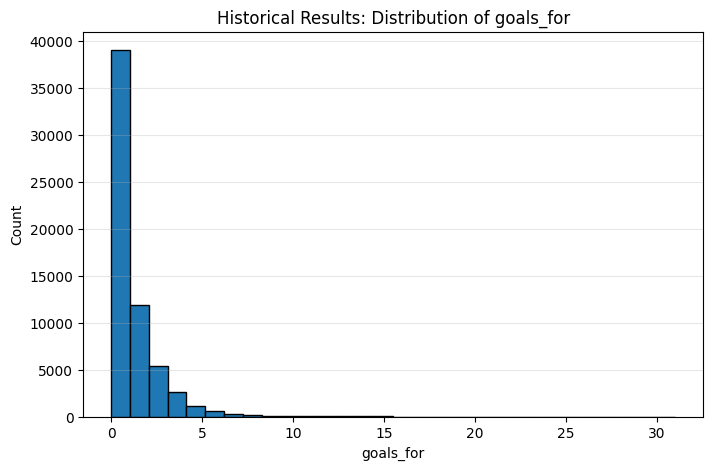

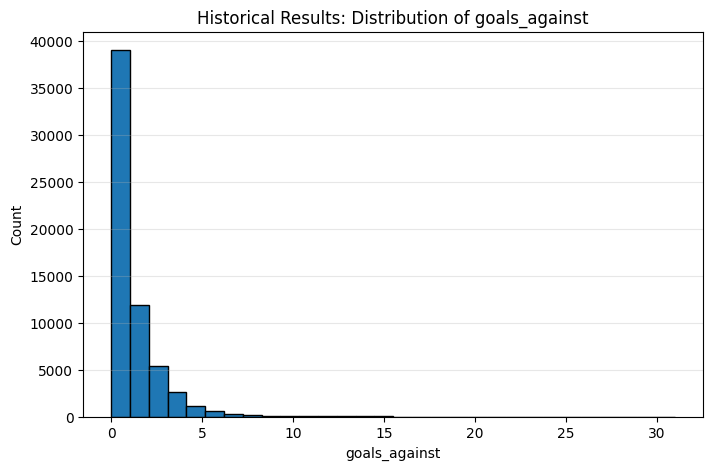

In [133]:
plot_all_numeric_hists(df_elo, dataset_name="Historical Results", bins=30)

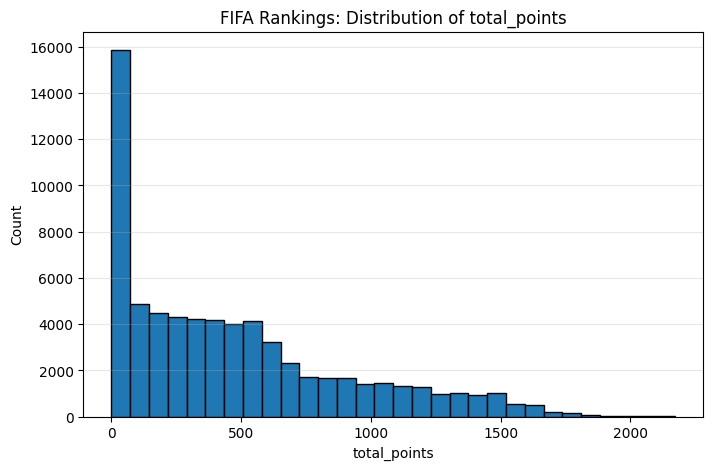

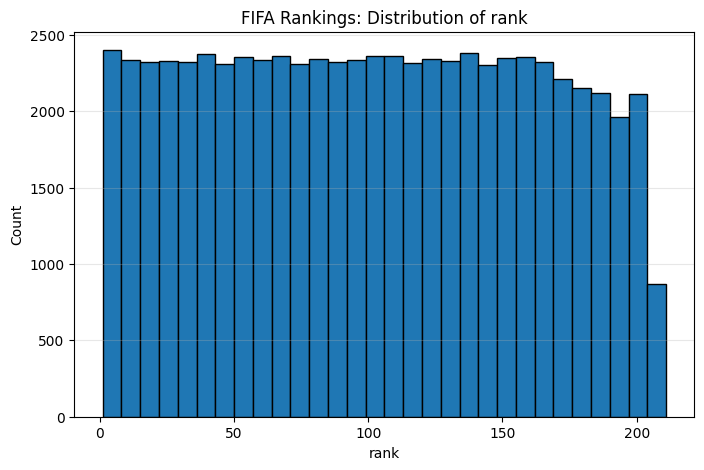

In [135]:
plot_all_numeric_hists(df_fifa, dataset_name="FIFA Rankings", bins=30)

First graph:
* Many rows have low total_points.
* Fewer teams have very high points.
* This is normal because only top teams have very high FIFA points.
* The big spike near low values may happen because older FIFA ranking systems used much smaller point scales than modern FIFA rankings.

Second graph: rank

This shows FIFA ranking positions.
Interpretation:

* Ranks are spread from around 1 to 200+.
* Lower rank is better:rank 1 = best team
* rank 200 = weak team

The distribution looks fairly flat because every FIFA ranking update contains many teams ranked across the whole range.

### Because FIFA points changed scale over time, raw total_points is not fully comparable across years. Normalize points within each ranking date or within each year.

### normalize by ranking date.

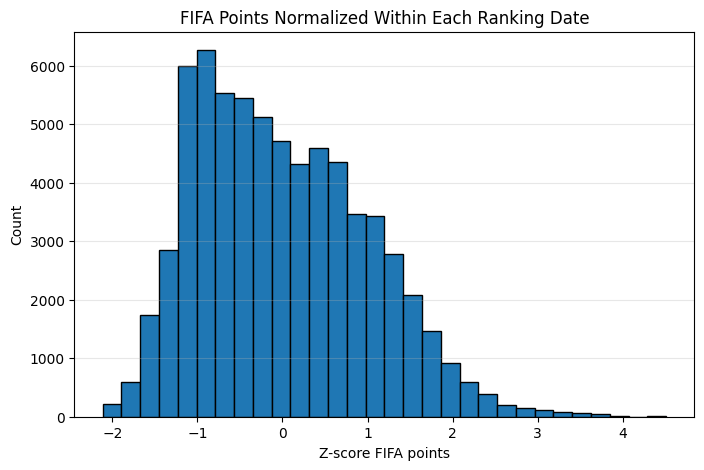

In [137]:
plot_hist(
    df_fifa,
    "fifa_points_zscore_by_date",
    title="FIFA Points Normalized Within Each Ranking Date",
    xlabel="Z-score FIFA points",
    bins=30
)

In [136]:
df_fifa["fifa_points_zscore_by_date"] = (
    df_fifa.groupby("date")["total_points"]
    .transform(lambda x: (x - x.mean()) / x.std())
)

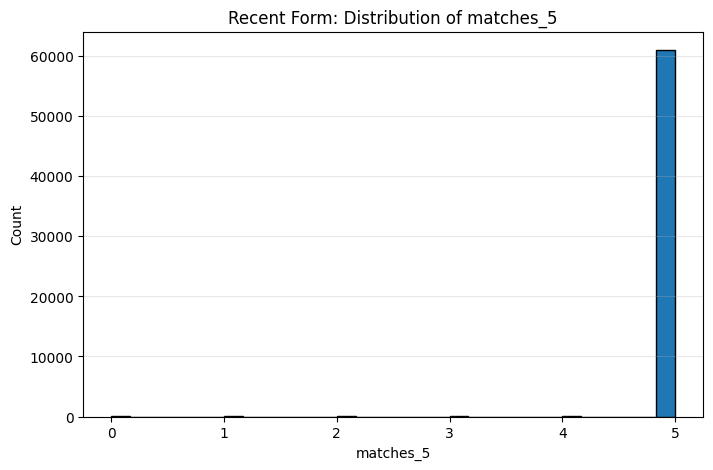

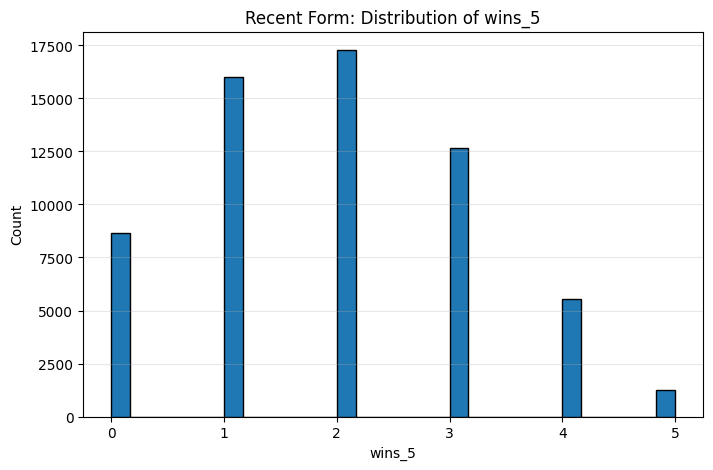

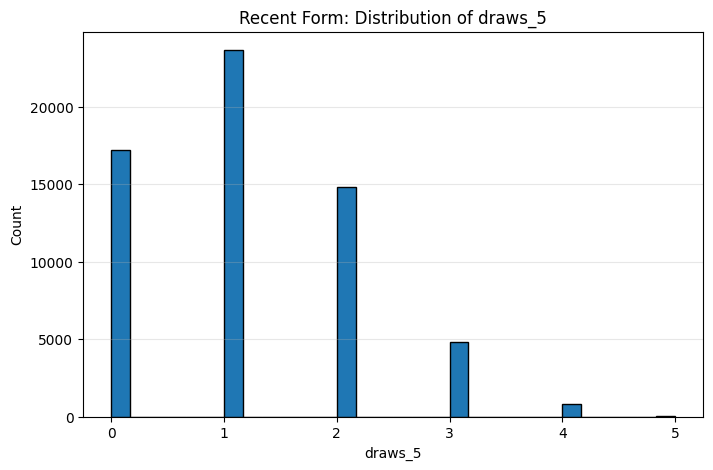

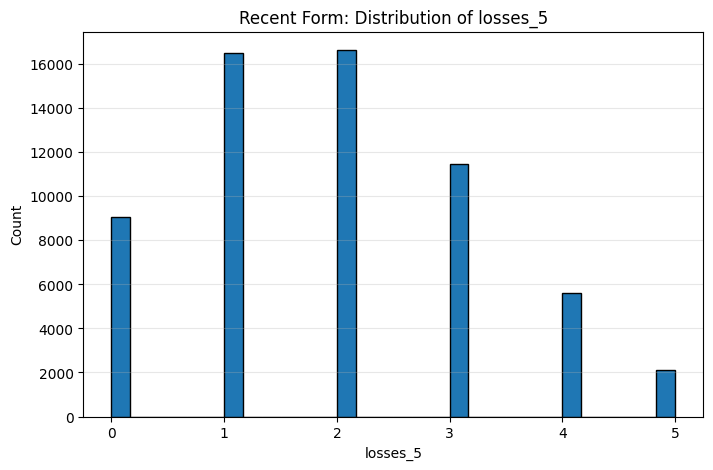

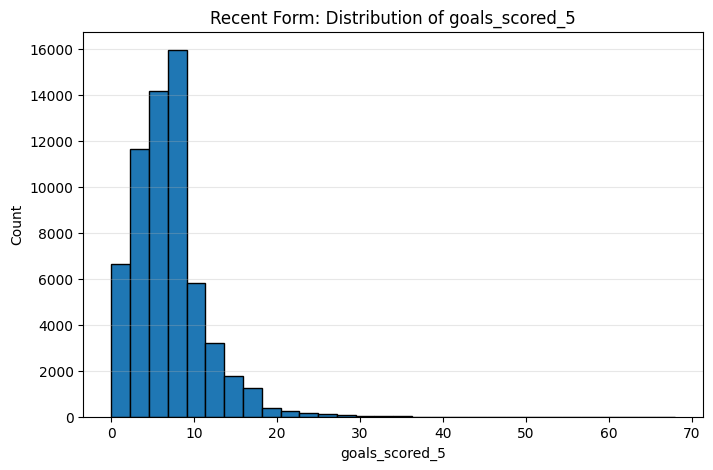

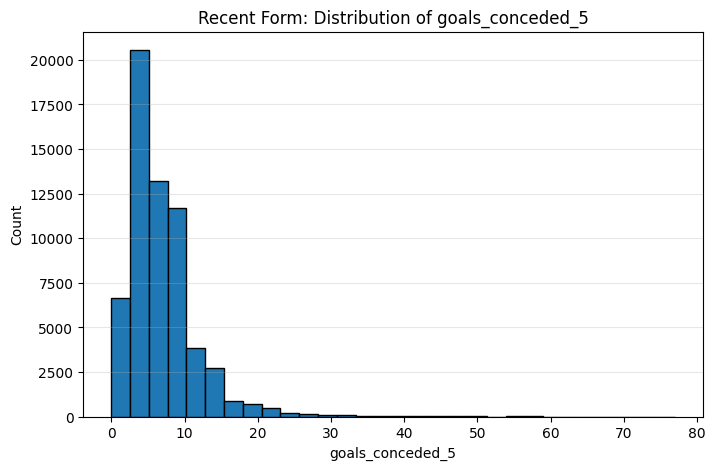

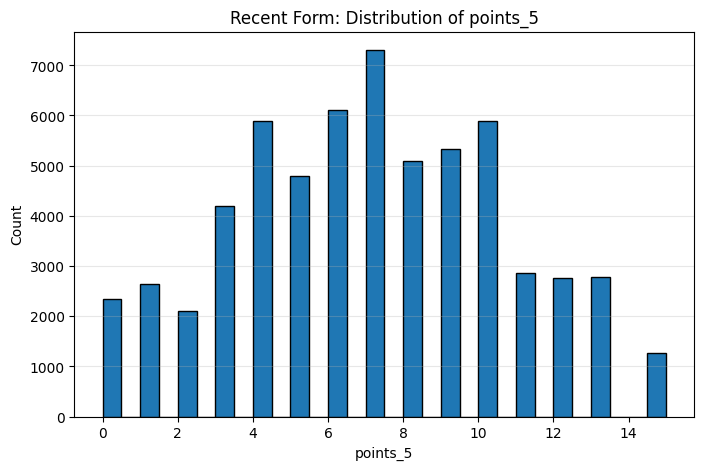

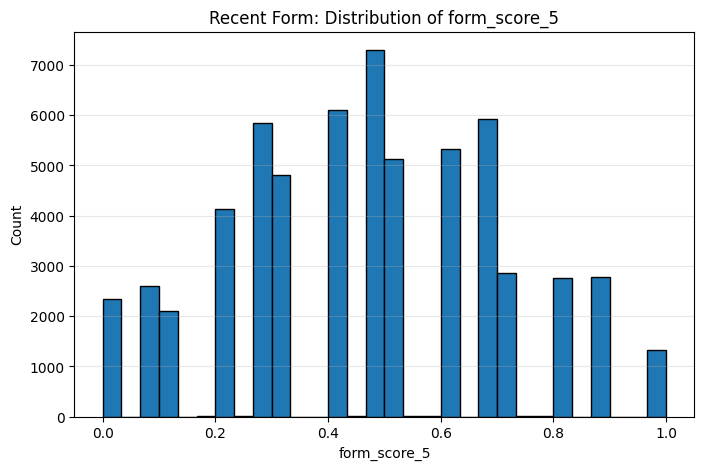

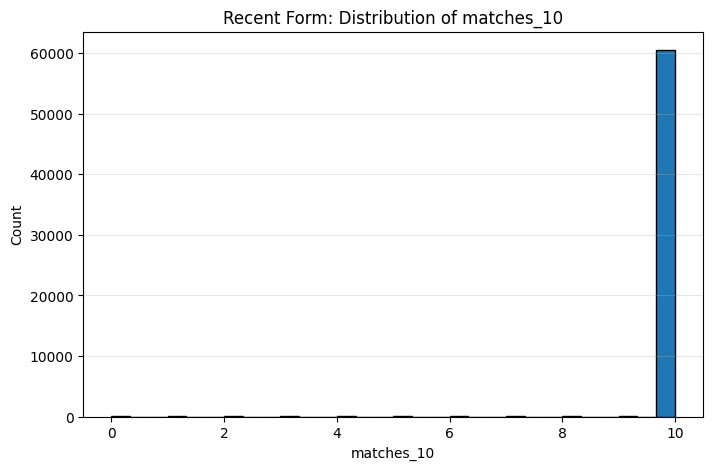

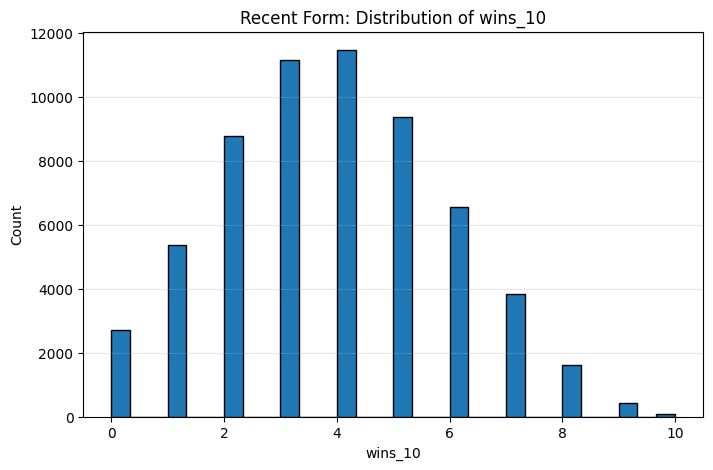

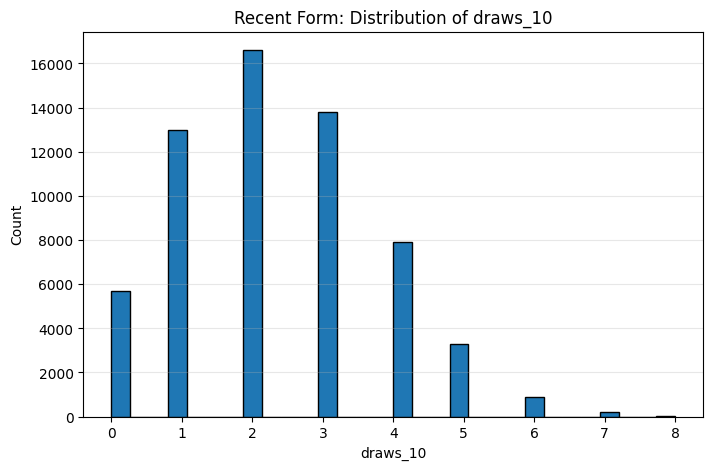

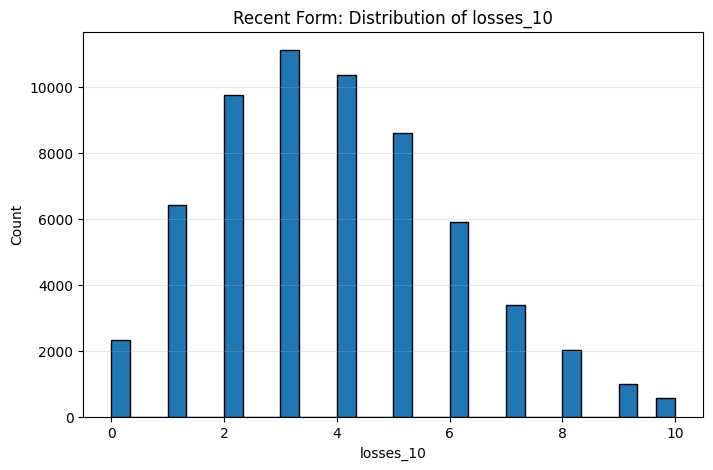

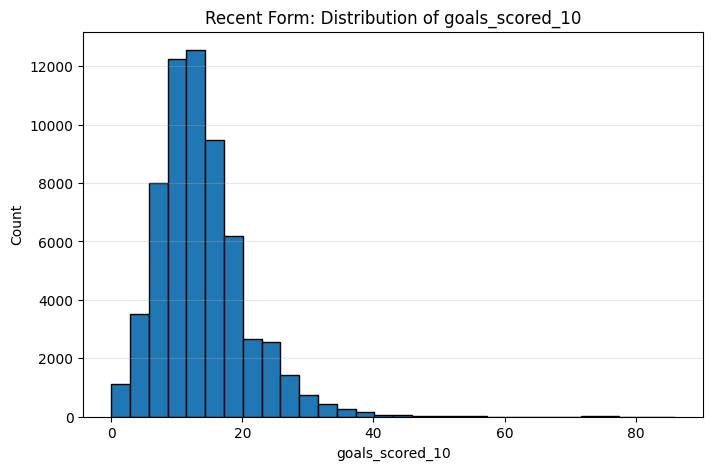

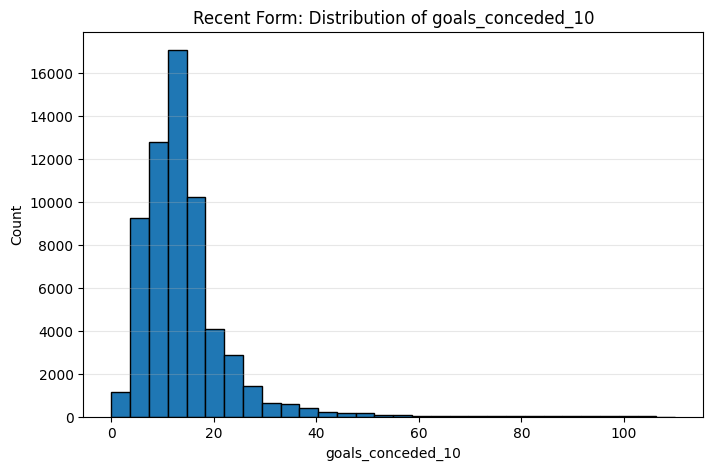

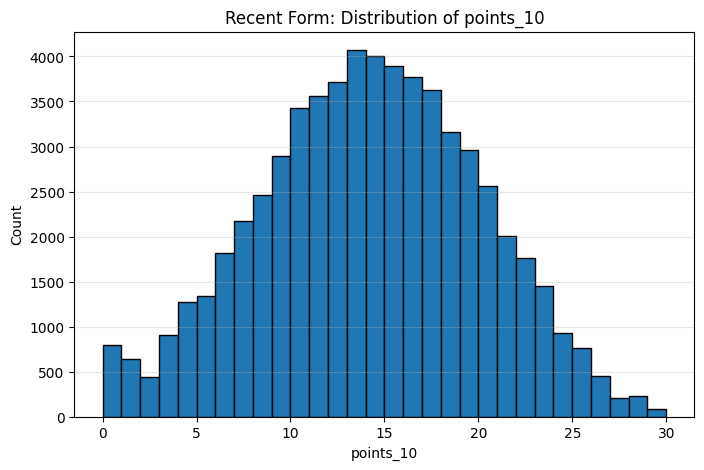

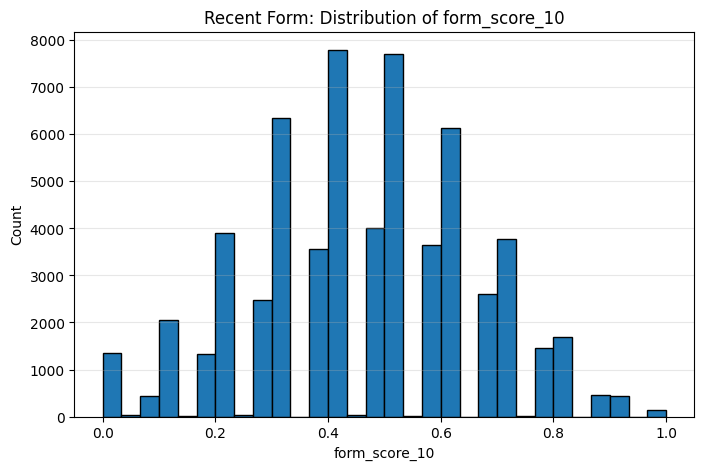

In [142]:
plot_all_numeric_hists(df_form, dataset_name="Recent Form", bins=30)

This checks wins_5 + draws_5 + losses_5 == matches_5

In [143]:
(df_form["wins_5"] + df_form["draws_5"] + df_form["losses_5"] == df_form["matches_5"]).mean()

np.float64(1.0)

This check for 10 

In [144]:
(df_form["wins_10"] + df_form["draws_10"] + df_form["losses_10"] == df_form["matches_10"]).mean()

np.float64(1.0)

Check points

In [147]:
points_5_valid = (df_form["points_5"] == df_form["wins_5"] * 3 + df_form["draws_5"])

print("Valid points_5 rows:", points_5_valid.mean())
print("Invalid points_5 rows:", (~points_5_valid).sum())

Valid points_5 rows: 1.0
Invalid points_5 rows: 0


In [148]:
points_10_valid = ( df_form["points_10"] == df_form["wins_10"] * 3 + df_form["draws_10"])

print("Valid points_10 rows:", points_10_valid.mean())
print("Invalid points_10 rows:", (~points_10_valid).sum())

Valid points_10 rows: 1.0
Invalid points_10 rows: 0


In [149]:
high_goal_form_5 = df_form[
    (df_form["goals_scored_5"] > 60) |
    (df_form["goals_conceded_5"] > 60)
].copy()

print("Rows with over 60 goals in last-5 form:", len(high_goal_form_5))

display(
    high_goal_form_5[
        [
            "date",
            "team",
            "opponent",
            "is_home",
            "matches_5",
            "wins_5",
            "draws_5",
            "losses_5",
            "goals_scored_5",
            "goals_conceded_5",
            "points_5",
            "form_score_5",
        ]
    ].sort_values(
        ["goals_scored_5", "goals_conceded_5"],
        ascending=False
    )
)

Rows with over 60 goals in last-5 form: 12


,date,team,opponent,is_home,matches_5,wins_5,draws_5,losses_5,goals_scored_5,goals_conceded_5,points_5,form_score_5
51203,2001-05-30,Australia,Mexico,False,5,4,0,1,68,3,12,0.8
51214,2001-06-01,Australia,France,True,5,5,0,0,68,0,15,1.0
41082,1995-08-21,Cook Islands,Solomon Islands,True,5,1,0,4,4,71,3,0.2
41091,1995-08-22,Cook Islands,Tahiti,False,5,1,0,4,3,71,3,0.2
41072,1995-08-19,Cook Islands,Wallis Islands and Futuna,True,4,0,0,4,2,70,0,0.0
41056,1995-08-16,Cook Islands,New Caledonia,True,3,0,0,3,2,61,0,0.0
52583,2002-03-14,American Samoa,Samoa,False,5,0,0,5,2,61,0,0.0
75656,2014-06-05,Darfur,Artsakh,True,5,0,0,5,1,77,0,0.0
75701,2014-06-07,Darfur,Tamil Eelam,False,5,0,0,5,1,74,0,0.0
38957,1993-12-11,Guam,Solomon Islands,False,5,0,0,5,1,63,0,0.0


This can happen because of very one-sided matches, especially with small/weak teams or regional tournaments.

The Australia example is probably driven by the famous 2001 Oceania qualifiers, where Australia had massive wins, including very high scorelines.
Is This A Problem?

For your current model, probably not a big problem if you only use:
* form_score_5
* form_score_10
because form_score_5 stays between 0 and 1.
But it is a problem if you use raw:
* goals_scored_5
* goals_conceded_5
because those extreme values can dominate the model.
Best Solution
we will not use raw goal totals directly. Use use the clip

In [150]:
df_form["goals_scored_5_capped"] = df_form["goals_scored_5"].clip(upper=df_form["goals_scored_5"].quantile(0.99))
df_form["goals_conceded_5_capped"] = df_form["goals_conceded_5"].clip(upper=df_form["goals_conceded_5"].quantile(0.99))

In [151]:
less_than_5_history = df_form[df_form["matches_5"] < 5].copy()

print("Rows with fewer than 5 previous matches:", len(less_than_5_history))
print("Share of df_form:", len(less_than_5_history) / len(df_form))

display(
    less_than_5_history[
        [
            "date",
            "team",
            "opponent",
            "is_home",
            "matches_5",
            "wins_5",
            "draws_5",
            "losses_5",
            "goals_scored_5",
            "goals_conceded_5",
            "points_5",
            "form_score_5",
        ]
    ].sort_values(["matches_5", "date"]).head(50)
)

Rows with fewer than 5 previous matches: 449
Share of df_form: 0.0073134182493403265


,date,team,opponent,is_home,matches_5,wins_5,draws_5,losses_5,goals_scored_5,goals_conceded_5,points_5,form_score_5
38411,1993-07-04,Isle of Man,Isle of Wight,False,0,0,0,0,0,0,0,0.0
38414,1993-07-04,Gibraltar,Jersey,True,0,0,0,0,0,0,0,0.0
38763,1993-10-13,North Macedonia,Slovenia,False,0,0,0,0,0,0,0,0.0
39133,1994-02-23,Czech Republic,Turkey,False,0,0,0,0,0,0,0,0.0
41423,1995-11-30,Bosnia and Herzegovina,Albania,False,0,0,0,0,0,0,0,0.0
41702,1996-02-06,Canary Islands,Venezuela,True,0,0,0,0,0,0,0,0.0
43036,1996-11-13,Andorra,Estonia,True,0,0,0,0,0,0,0,0.0
44275,1997-06-29,Frøya,Jersey,False,0,0,0,0,0,0,0,0.0
44279,1997-06-29,Hitra,Ynys Môn,False,0,0,0,0,0,0,0,0.0
45358,1998-03-22,United States Virgin Islands,British Virgin Islands,True,0,0,0,0,0,0,0,0.0


In [152]:
df_form["matches_5"].value_counts().sort_index()

matches_5
0       93
1       92
2       87
3       88
4       89
5    60945
Name: count, dtype: int64

Rows with fewer than 5 previous matches: 449

Share of df_form: 0.0073 = 0.73%

* matches_5 = 0      93 rows
* matches_5 = 1      92 rows
* matches_5 = 2      87 rows
* matches_5 = 3      88 rows
* matches_5 = 4      89 rows
* matches_5 = 5   60945 rows

That is healthy. Most rows have full history.

### Recent Form History Availability

I checked whether each team had enough previous matches to calculate reliable recent-form features.

For the last-5-match form features, I created:

- `has_full_form_5`: `True` when the team has exactly 5 previous matches.
- `has_any_form_5`: `True` when the team has at least 1 previous match.

For the last-10-match form features, I created:

- `has_full_form_10`: `True` when the team has exactly 10 previous matches.
- `has_any_form_10`: `True` when the team has at least 1 previous match.

This matters because a `form_score` of 0 can mean two different things:

1. the team had poor recent form, or
2. the team had no previous match history available.

To avoid confusing “bad form” with “missing history,” I kept the form values but added these flags so the model can learn the difference.

In [154]:
df_form["has_full_form_5"] = df_form["matches_5"] == 5
df_form["has_any_form_5"] = df_form["matches_5"] > 0

In [155]:
df_form["has_full_form_10"] = df_form["matches_10"] == 10
df_form["has_any_form_10"] = df_form["matches_10"] > 0

In [156]:
form_history_summary = pd.DataFrame({
    "check": [
        "Full 5-match history",
        "Any 5-match history",
        "No 5-match history",
        "Partial 5-match history",
        "Full 10-match history",
        "Any 10-match history",
        "No 10-match history",
        "Partial 10-match history",
    ],
    "rows": [
        df_form["has_full_form_5"].sum(),
        df_form["has_any_form_5"].sum(),
        (~df_form["has_any_form_5"]).sum(),
        ((df_form["has_any_form_5"]) & (~df_form["has_full_form_5"])).sum(),
        df_form["has_full_form_10"].sum(),
        df_form["has_any_form_10"].sum(),
        (~df_form["has_any_form_10"]).sum(),
        ((df_form["has_any_form_10"]) & (~df_form["has_full_form_10"])).sum(),
    ]
})

form_history_summary["percentage"] = (
    form_history_summary["rows"] / len(df_form) * 100
).round(2)

display(form_history_summary)

,check,rows,percentage
0,Full 5-match history,60945,99.27
1,Any 5-match history,61301,99.85
2,No 5-match history,93,0.15
3,Partial 5-match history,356,0.58
4,Full 10-match history,60505,98.55
5,Any 10-match history,61301,99.85
6,No 10-match history,93,0.15
7,Partial 10-match history,796,1.30


Why:
* Dropping rows removes real matches.
* New/rare teams may appear in prediction too, so the model should learn how to handle limited history.
* The flags tell the model when form is based on incomplete data.

Version A: keep all rows

In [157]:
df_form_model = df_form.copy()

Version B: keep only full 5-match history

In [158]:
df_form_full_5 = df_form[df_form["has_full_form_5"]].copy()

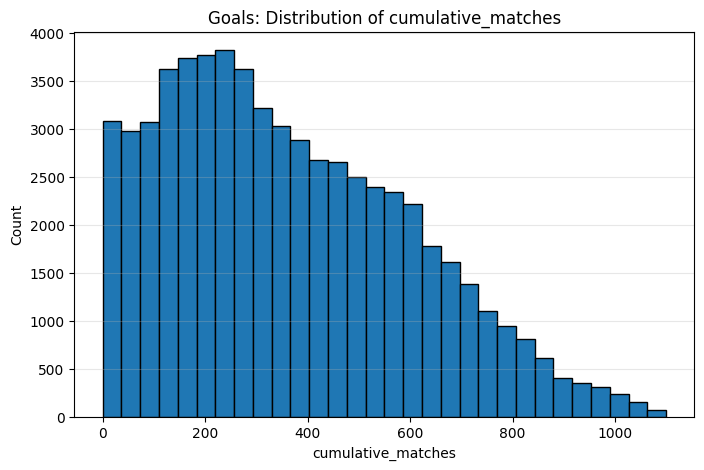

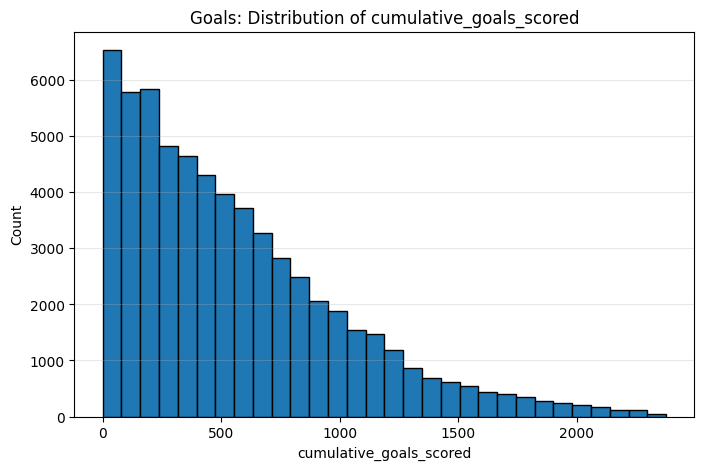

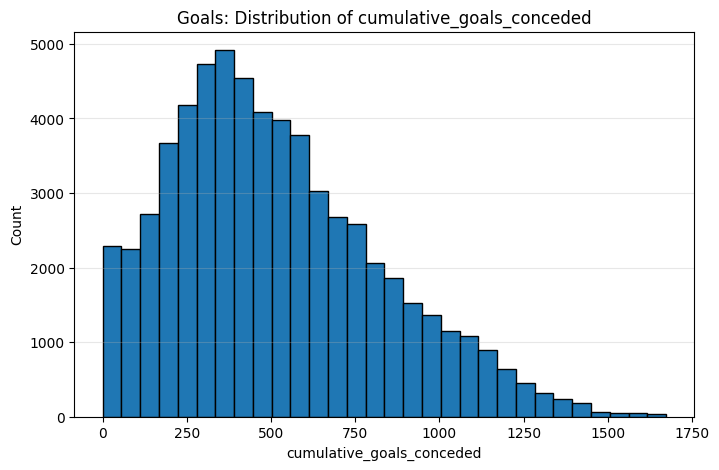

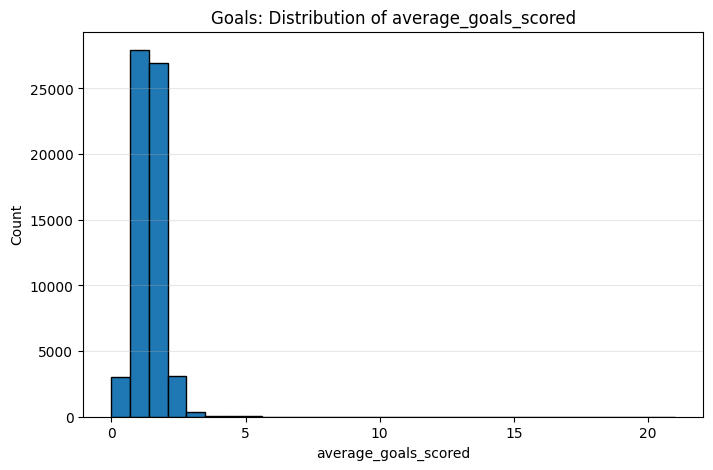

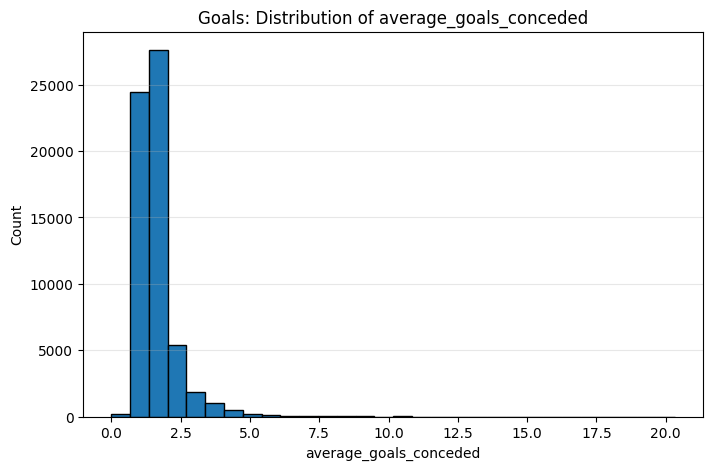

In [161]:
plot_all_numeric_hists(df_goals, dataset_name= "Goals", bins=30)

But add a reliability flag from cumulative_matches

In [162]:
df_goals["has_enough_goal_history"] = df_goals["cumulative_matches"] >= 10

### Goal Scoring and Conceding Features

For the goals dataset, I will use `average_goals_scored` and `average_goals_conceded` instead of cumulative goal totals.

The cumulative columns mostly reflect how long a team has existed or how many matches it has played. Older teams naturally have higher cumulative goals, even if they are not stronger.

The average columns are more useful because they describe team performance per match:

- `average_goals_scored`: how many goals a team usually scores per match
- `average_goals_conceded`: how many goals a team usually allows per match

These features are better for comparing teams with different history lengths.

I also cap extreme average goal values to reduce the influence of unusual small-sample teams or very one-sided historical matches.

In [ ]:
df_goals["average_goals_scored_capped"] = df_goals["average_goals_scored"].clip(upper=6)
df_goals["average_goals_conceded_capped"] = df_goals["average_goals_conceded"].clip(upper=6)

In [166]:
plot_all_numeric_hists(df_home, dataset_name= "Home", bins=30)

### Home and Region Advantage Features

The home-region dataset does not produce useful numeric histograms because most of its important columns are boolean features.

These columns represent whether a team has a location advantage, for example whether the match is played in the home team's country or confederation.

Because they are `True` / `False` variables, they are better checked with value counts rather than histograms.

In [167]:
home_bool_cols = [
    "neutral",
    "is_home_country",
    "is_away_country",
    "is_home_confed",
    "is_away_confed",
]

for col in home_bool_cols:
    print(f"\n{col}")
    display(df_home[col].value_counts(normalize=True).rename("share"))


neutral


neutral
False    0.715386
True     0.284614
Name: share, dtype: float64


is_home_country


is_home_country
True     0.703458
False    0.296542
Name: share, dtype: float64


is_away_country


is_away_country
False    0.999967
True     0.000033
Name: share, dtype: float64


is_home_confed


is_home_confed
True     0.928627
False    0.071373
Name: share, dtype: float64


is_away_confed


is_away_confed
True     0.802067
False    0.197933
Name: share, dtype: float64

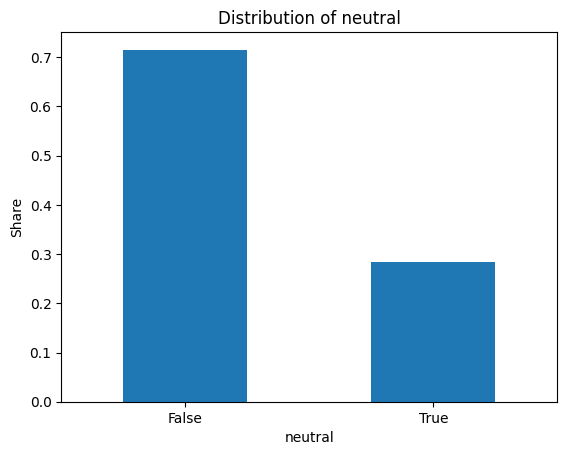

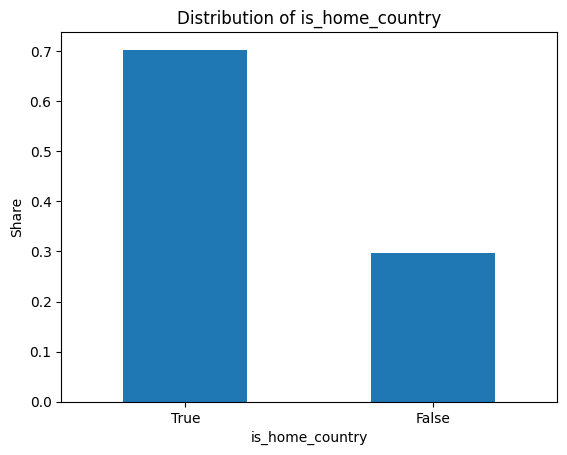

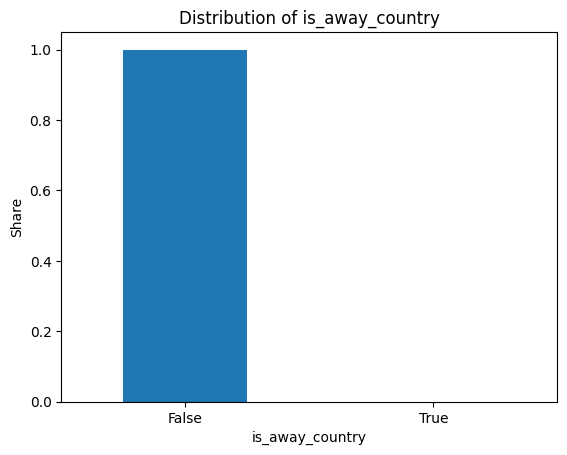

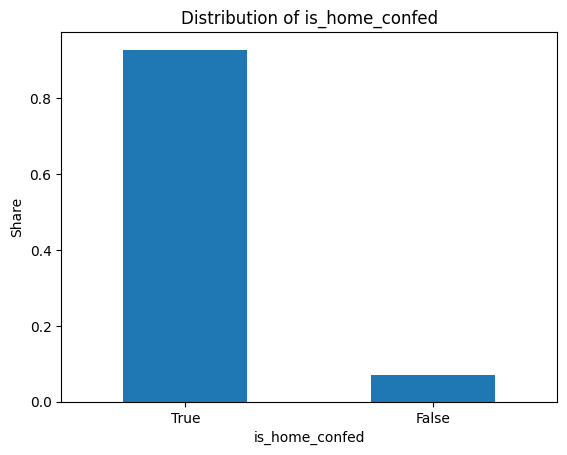

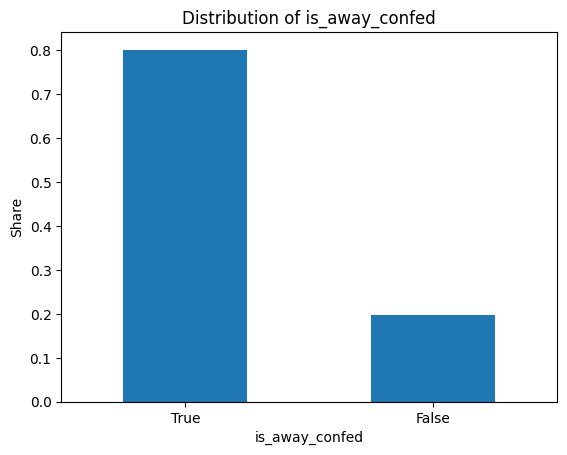

In [168]:
for col in home_bool_cols:
    df_home[col].value_counts(normalize=True).plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.ylabel("Share")
    plt.xticks(rotation=0)
    plt.show()

The home-region advantage features are mostly boolean variables, so I checked their True/False proportions instead of using histograms.

Most matches are not neutral and the listed home team often plays in its own country or confederation. The `is_away_country` feature has almost no variation, meaning it is unlikely to provide much predictive value compared with the other home/region features.

In [169]:
df_home["is_away_country"].value_counts()

is_away_country
False    30767
True         1
Name: count, dtype: int64

I checked `is_away_country` and found that it is `True` for only one match. Because the feature has almost no variation, it is unlikely to help the model and may add noise. I saved the matching row separately for reference, then removed the column from the modeling dataset.

In [170]:
away_country_true = df_home[df_home["is_away_country"] == True].copy()

display(
    away_country_true[
        [
            "date",
            "home_team",
            "away_team",
            "country",
            "neutral",
            "is_home_country",
            "is_away_country",
            "is_home_confed",
            "is_away_confed",
        ]
    ]
)

,date,home_team,away_team,country,neutral,is_home_country,is_away_country,is_home_confed,is_away_confed
30548,2006-12-09,Silesia,Poland,Poland,False,False,True,True,True


In [171]:
away_country_true_matches = away_country_true[
    ["date", "home_team", "away_team", "country"]
].copy()

In [172]:
df_home = df_home.drop(columns=["is_away_country"])

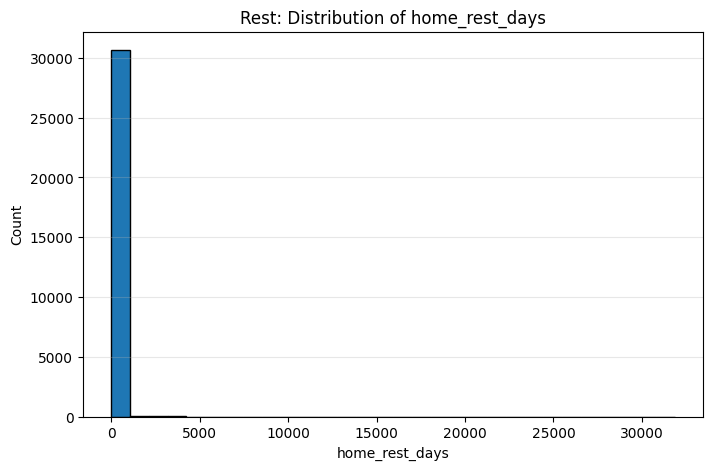

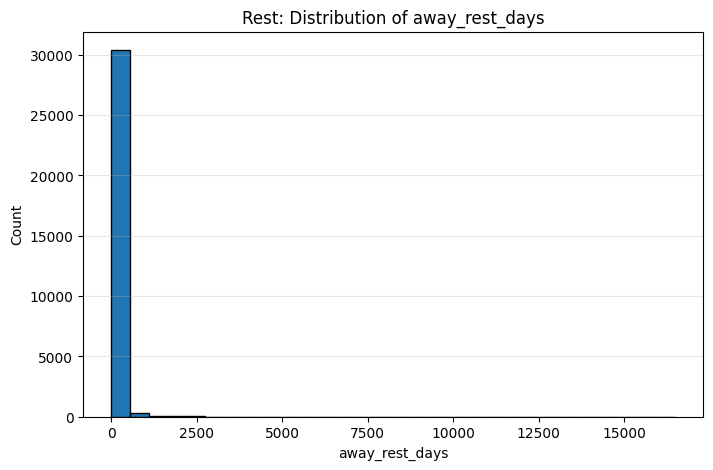

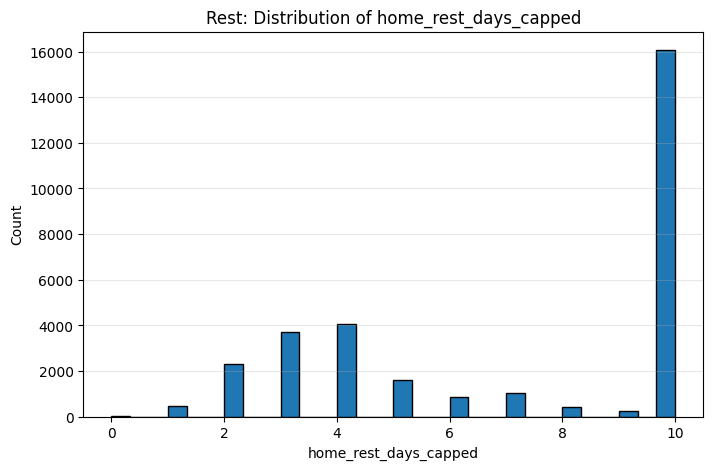

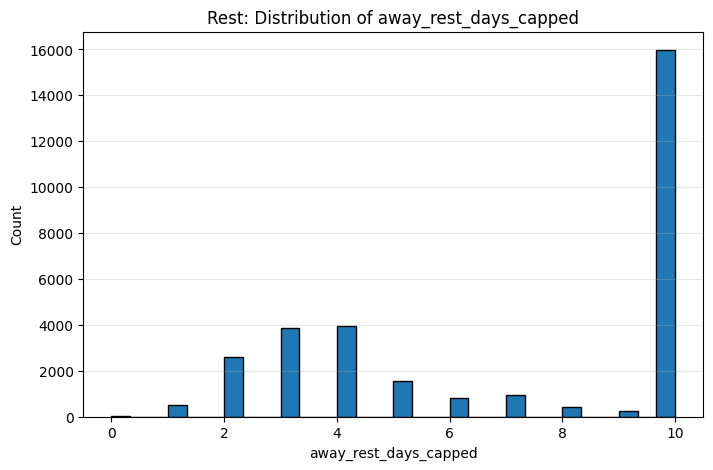

In [173]:
plot_all_numeric_hists(df_rest, dataset_name= "Rest", bins=30)

### Rest Days Features

The raw rest-day columns contain very large outliers because some teams have long gaps between recorded matches. These large values are not very meaningful for match prediction, since the practical difference between 300 and 1000 days of rest is not useful.

For modeling, I use the capped rest-day columns instead. In these columns, any rest period above 10 days is treated as 10. This keeps the useful signal from short recovery periods while reducing the impact of extreme gaps between matches.

In [177]:
df_rest["rest_days_diff"] = (
    df_rest["home_rest_days_capped"] -
    df_rest["away_rest_days_capped"]
)

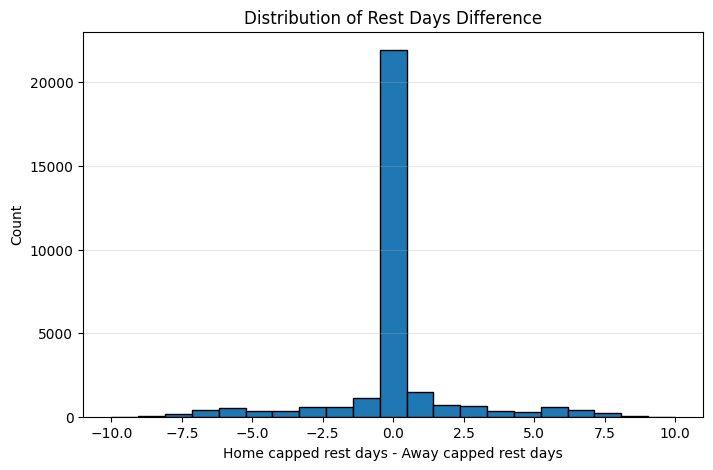

In [178]:
plot_hist(
    df_rest,
    "rest_days_diff",
    title="Distribution of Rest Days Difference",
    xlabel="Home capped rest days - Away capped rest days",
    bins=21
)

The rest-day difference feature compares recovery time between the two teams. A value of 0 means both teams had equal rest, positive values mean the home team had more rest, and negative values mean the away team had more rest.

Most matches have equal rest, but some matches show meaningful rest advantages for one side. This makes `rest_days_diff` a useful feature for the model because it captures relative recovery advantage rather than raw rest-day totals.

In [179]:
df_rest["rest_days_diff"].value_counts().sort_index()

rest_days_diff
-10.0        2
-9.0        56
-8.0       172
-7.0       400
-6.0       509
-5.0       327
-4.0       315
-3.0       597
-2.0       587
-1.0      1111
 0.0     21929
 1.0      1484
 2.0       698
 3.0       642
 4.0       367
 5.0       302
 6.0       577
 7.0       401
 8.0       249
 9.0        41
 10.0        2
Name: count, dtype: int64

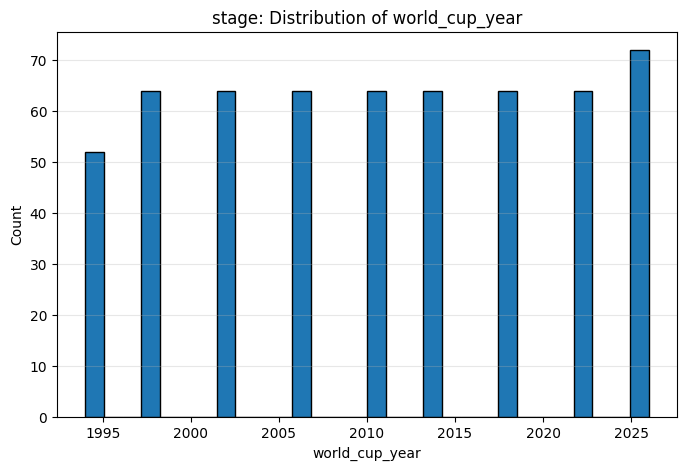

In [174]:
plot_all_numeric_hists(df_stage, dataset_name= "stage", bins=30)

In [175]:
df_stage["stage"].value_counts()

stage
Group Stage             444
Round of 16              64
Quarter-finals           32
Semi-finals              16
Third-place play-off      8
Final                     8
Name: count, dtype: int64

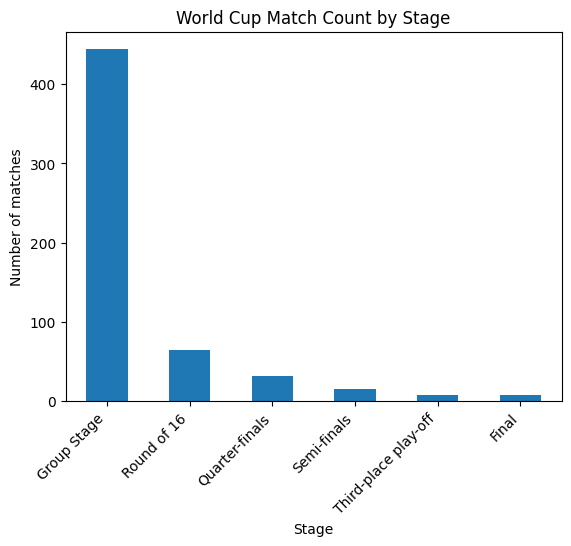

In [176]:
df_stage["stage"].value_counts().plot(kind="bar")
plt.title("World Cup Match Count by Stage")
plt.xlabel("Stage")
plt.ylabel("Number of matches")
plt.xticks(rotation=45, ha="right")
plt.show()

In [181]:
def plot_bar_counts(df, column, title=None, xlabel=None, ylabel=None, normalize=False, top_n=None):
    values = df[column].value_counts(normalize=normalize)

    if top_n is not None:
        values = values.head(top_n)

    plt.figure(figsize=(8, 5))
    values.plot(kind="bar", edgecolor="black")

    plt.title(title or f"Distribution of {column}")
    plt.xlabel(xlabel or column)
    plt.ylabel(ylabel or ("Share" if normalize else "Count"))
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

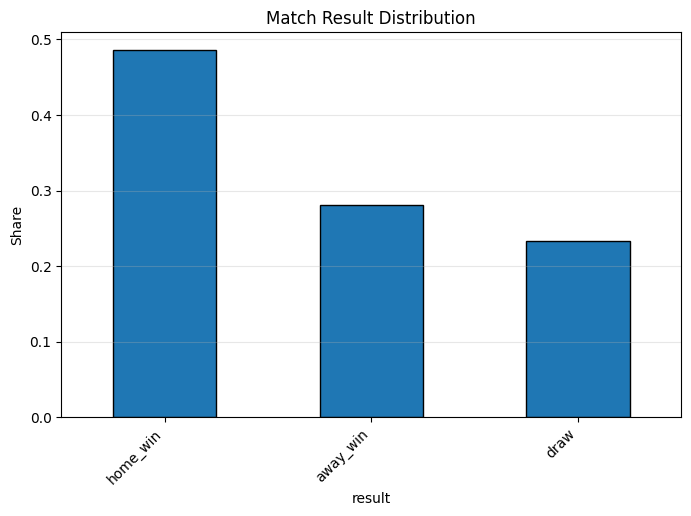

In [182]:
plot_bar_counts(df_res, "result", title="Match Result Distribution", normalize=True)

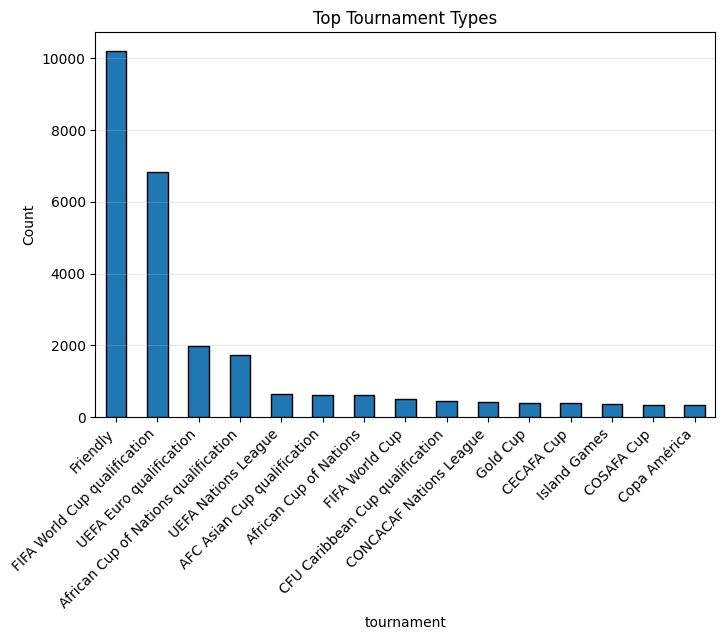

In [183]:
plot_bar_counts(
    df_res,
    "tournament",
    title="Top Tournament Types",
    top_n=15
)

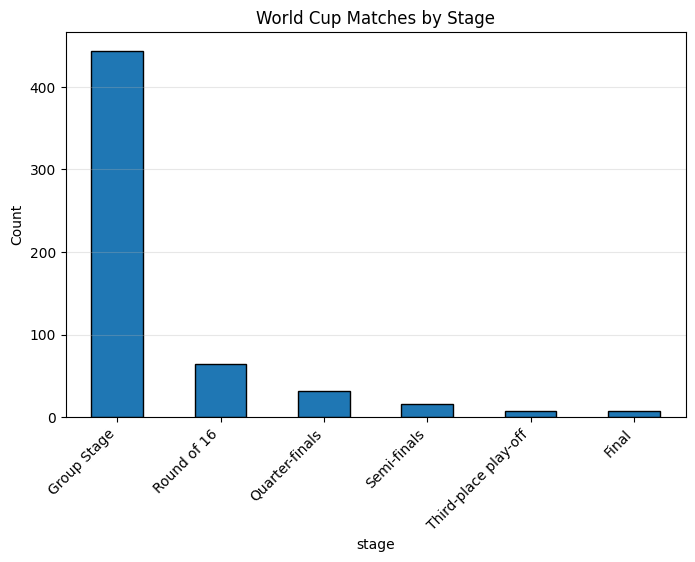

In [184]:
plot_bar_counts(
    df_stage,
    "stage",
    title="World Cup Matches by Stage"
)

Matches per year:

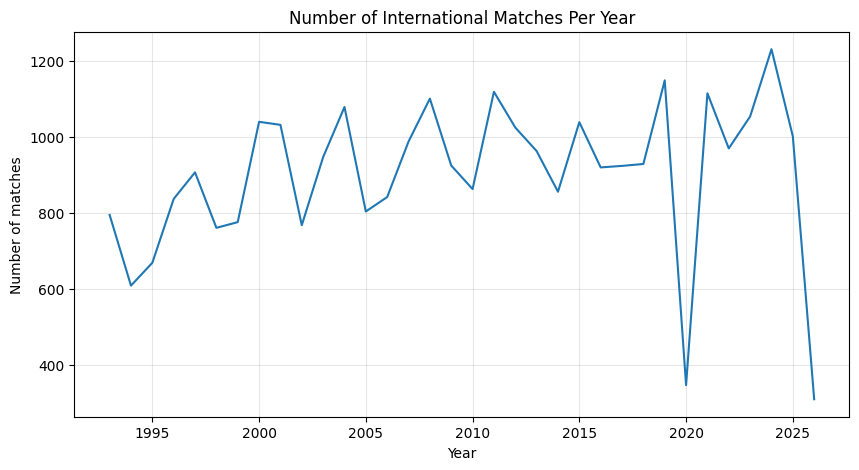

In [186]:
matches_per_year = df_res.groupby(df_res["date"].dt.year).size()

plt.figure(figsize=(10, 5))
matches_per_year.plot()
plt.title("Number of International Matches Per Year")
plt.xlabel("Year")
plt.ylabel("Number of matches")
plt.grid(alpha=0.3)
plt.show()

Average goals per year:

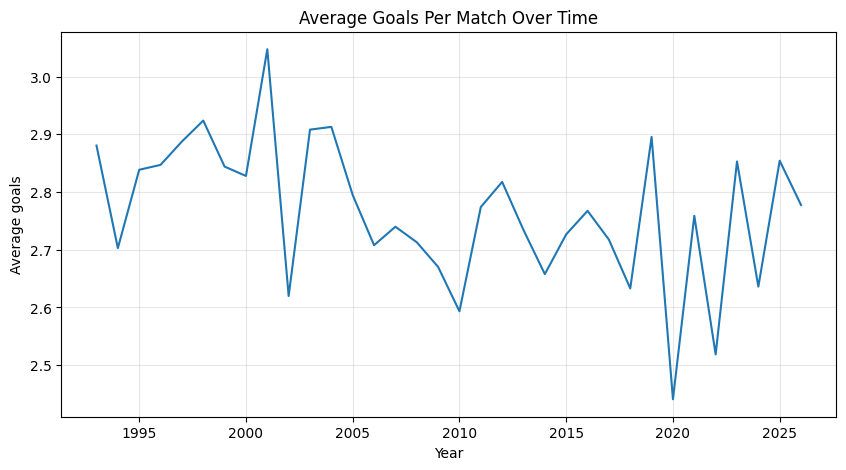

In [187]:
goals_per_year = df_res.assign(
    total_goals=df_res["home_score"] + df_res["away_score"]
).groupby(df_res["date"].dt.year)["total_goals"].mean()

plt.figure(figsize=(10, 5))
goals_per_year.plot()
plt.title("Average Goals Per Match Over Time")
plt.xlabel("Year")
plt.ylabel("Average goals")
plt.grid(alpha=0.3)
plt.show()

### Match Volume and Goal Trends Over Time

The number of international matches per year is generally stable, with most years having around 800 to 1200 matches. The sharp drop in 2020 is expected because of COVID-related cancellations, and the lower value in 2026 is expected because the year is only partially complete in the dataset.

Average goals per match remain mostly between 2.6 and 2.9 across years. This suggests that scoring levels are reasonably stable in the modern era, with some natural year-to-year variation.

These plots do not show a major data-quality issue, but they confirm that time-based validation is important because match volume and football conditions can vary by year.

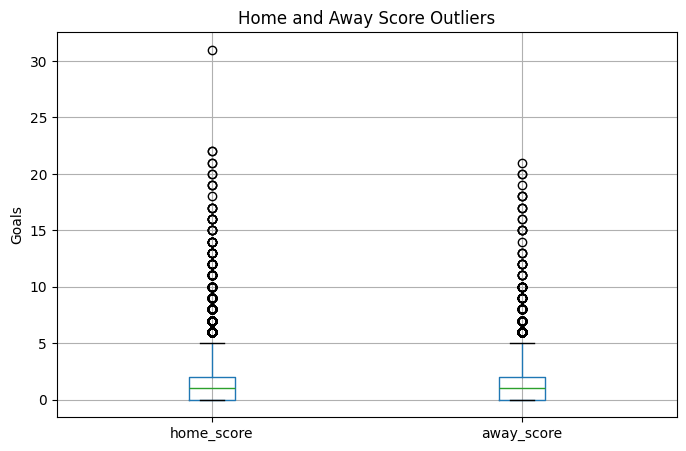

In [188]:
plt.figure(figsize=(8, 5))
df_res[["home_score", "away_score"]].boxplot()
plt.title("Home and Away Score Outliers")
plt.ylabel("Goals")
plt.show()

In [246]:
score_outliers = df_res[
    (df_res["home_score"] >= 10) |
    (df_res["away_score"] >= 10)
].copy()

display(
    score_outliers[
        ["date", "home_team", "away_team", "home_score", "away_score", "tournament"]
    ].sort_values(["home_score", "away_score"], ascending=False)
)

,date,home_team,away_team,home_score,away_score,tournament
25424,2001-04-11,Australia,American Samoa,31.0,0.0,FIFA World Cup qualification
25421,2001-04-09,Australia,Tonga,22.0,0.0,FIFA World Cup qualification
37060,2013-06-24,Provence,Tibet,22.0,0.0,"International Tournament of Peoples, Cultures ..."
30517,2006-11-24,Sápmi,Monaco,21.0,1.0,Viva World Cup
37058,2013-06-23,Quebec,Tibet,21.0,0.0,"International Tournament of Peoples, Cultures ..."
...,...,...,...,...,...,...
44013,2021-06-05,Turks and Caicos Islands,Haiti,0.0,10.0,FIFA World Cup qualification
44084,2021-06-11,Cambodia,Iran,0.0,10.0,FIFA World Cup qualification
44729,2021-11-15,San Marino,England,0.0,10.0,FIFA World Cup qualification
45393,2022-06-13,São Tomé and Príncipe,Nigeria,0.0,10.0,African Cup of Nations qualification


In [248]:
df_res["is_extreme_scoreline"] = (
    (df_res["home_score"] >= 10) |
    (df_res["away_score"] >= 10)
)

### Score Outliers

The boxplot shows that most football matches have low scores, usually between 0 and 2 goals per team. However, there are some extreme scorelines above 10 goals.

These outliers are not necessarily data errors, but they can strongly affect score prediction models. For winner prediction they are less problematic because the target is only win, draw, or loss.

I flag extreme scorelines so they can be reviewed and handled carefully during score modeling.

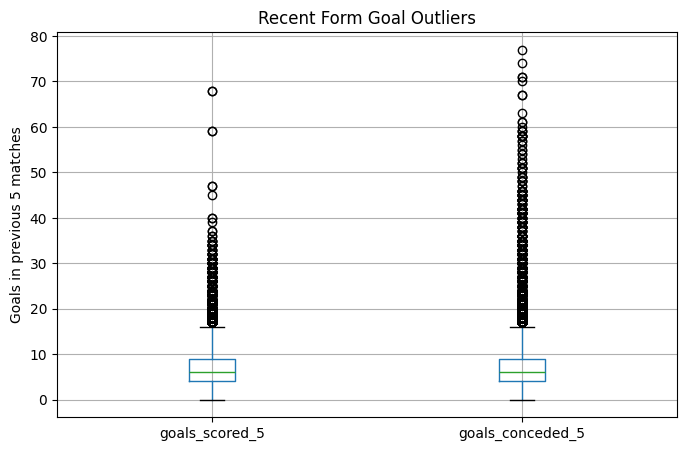

In [189]:
plt.figure(figsize=(8, 5))
df_form[["goals_scored_5", "goals_conceded_5"]].boxplot()
plt.title("Recent Form Goal Outliers")
plt.ylabel("Goals in previous 5 matches")
plt.show()

In [196]:
def plot_scatter(df, x, y, title=None, xlabel=None, ylabel=None, alpha=0.3):
    plt.figure(figsize=(8, 5))
    plt.scatter(df[x], df[y], alpha=alpha)
    plt.title(title or f"{x} vs {y}")
    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    plt.grid(alpha=0.3)
    plt.show()

### For df_res

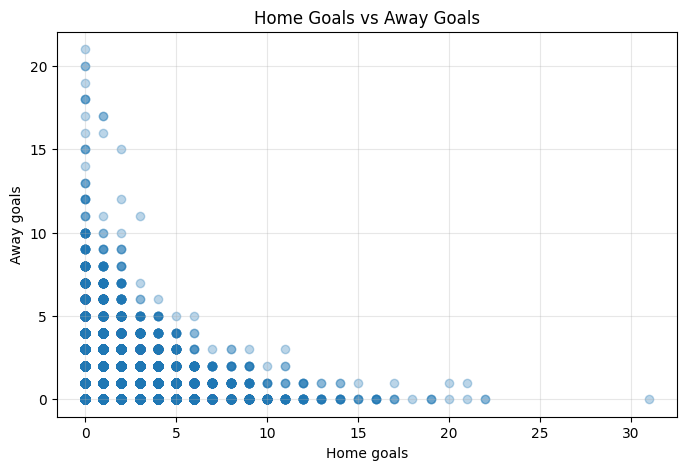

In [197]:
plot_scatter(
    df_res,
    "home_score",
    "away_score",
    title="Home Goals vs Away Goals",
    xlabel="Home goals",
    ylabel="Away goals"
)

### For df_elo

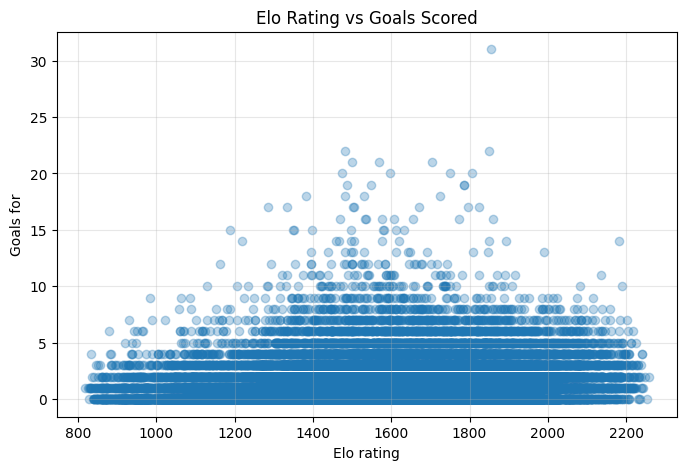

In [198]:
plot_scatter(
    df_elo,
    "elo_rating",
    "goals_for",
    title="Elo Rating vs Goals Scored",
    xlabel="Elo rating",
    ylabel="Goals for"
)

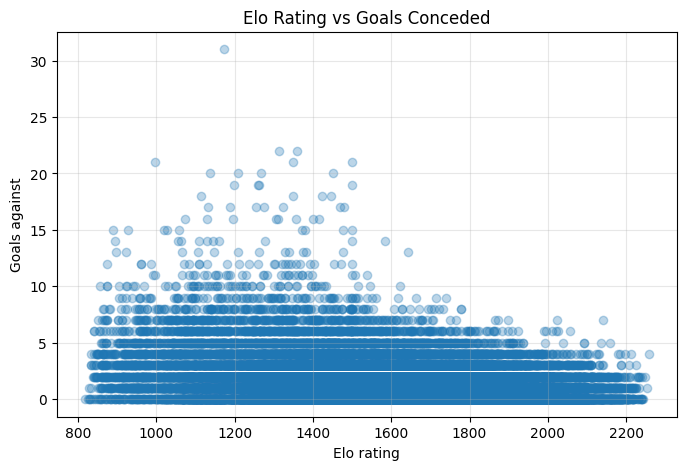

In [199]:
plot_scatter(
    df_elo,
    "elo_rating",
    "goals_against",
    title="Elo Rating vs Goals Conceded",
    xlabel="Elo rating",
    ylabel="Goals against"
)

Not “more games = more goals” columns.

But they are still not the best scatter plots, because football goals are discrete and noisy. A high-Elo team can score 0, 1, 2, 3, etc. in one match.

A better idea is to plot average goals by Elo rating bins.

In [200]:
df_elo_plot = df_elo.copy()

df_elo_plot["elo_bin"] = pd.cut(
    df_elo_plot["elo_rating"],
    bins=10
)

elo_goal_summary = (
    df_elo_plot
    .groupby("elo_bin", observed=True)
    .agg(
        avg_goals_for=("goals_for", "mean"),
        avg_goals_against=("goals_against", "mean"),
        matches=("goals_for", "size")
    )
    .reset_index()
)

display(elo_goal_summary)

,elo_bin,avg_goals_for,avg_goals_against,matches
0,"(816.442, 961.876]",0.716912,3.038603,544
1,"(961.876, 1105.869]",0.797306,2.819756,1559
2,"(1105.869, 1249.862]",0.869916,2.450084,2975
3,"(1249.862, 1393.856]",1.150402,1.884558,6722
4,"(1393.856, 1537.849]",1.288416,1.473288,13009
5,"(1537.849, 1681.842]",1.396959,1.223200,14664
6,"(1681.842, 1825.836]",1.517985,1.060059,12288
7,"(1825.836, 1969.829]",1.708501,0.963228,6717
8,"(1969.829, 2113.822]",1.937037,0.874897,2430
9,"(2113.822, 2257.815]",2.189300,0.759259,486


### Do higher Elo teams score more and concede less on average? The below graph answer this

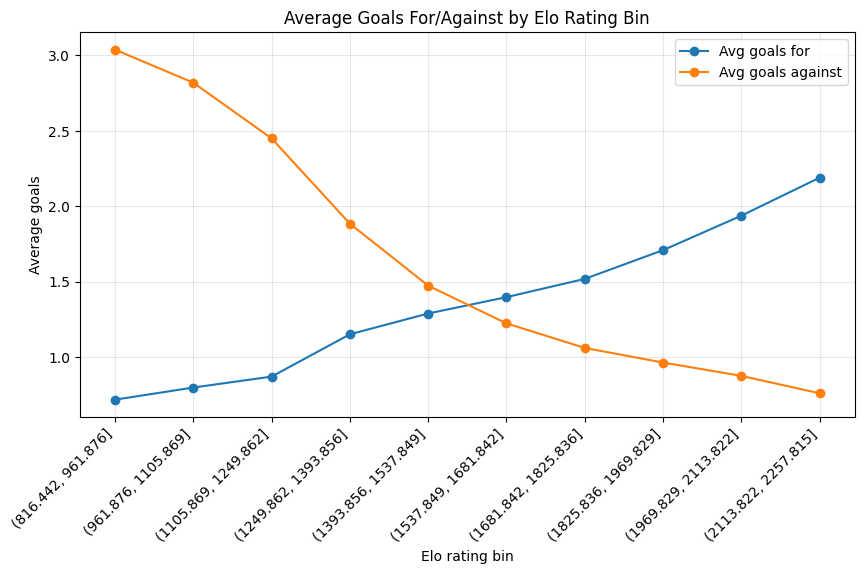

In [202]:
plt.figure(figsize=(10, 5))

plt.plot(
    elo_goal_summary["elo_bin"].astype(str),
    elo_goal_summary["avg_goals_for"],
    marker="o",
    label="Avg goals for"
)

plt.plot(
    elo_goal_summary["elo_bin"].astype(str),
    elo_goal_summary["avg_goals_against"],
    marker="o",
    label="Avg goals against"
)

plt.title("Average Goals For/Against by Elo Rating Bin")
plt.xlabel("Elo rating bin")
plt.ylabel("Average goals")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

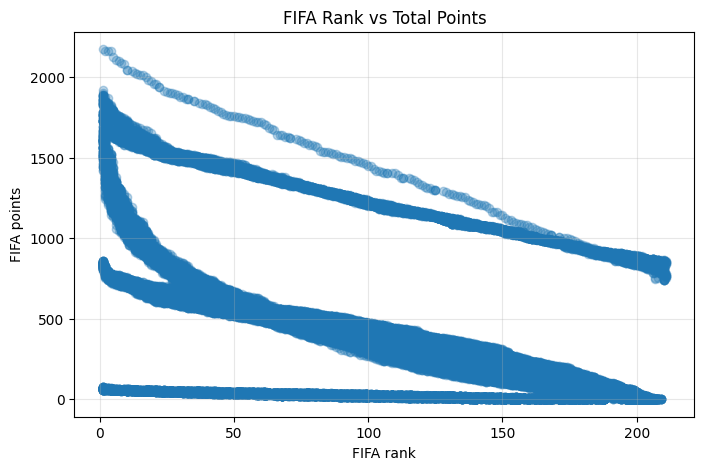

In [203]:
plot_scatter(
    df_fifa,
    "rank",
    "total_points",
    title="FIFA Rank vs Total Points",
    xlabel="FIFA rank",
    ylabel="FIFA points"
)

The normalised points 

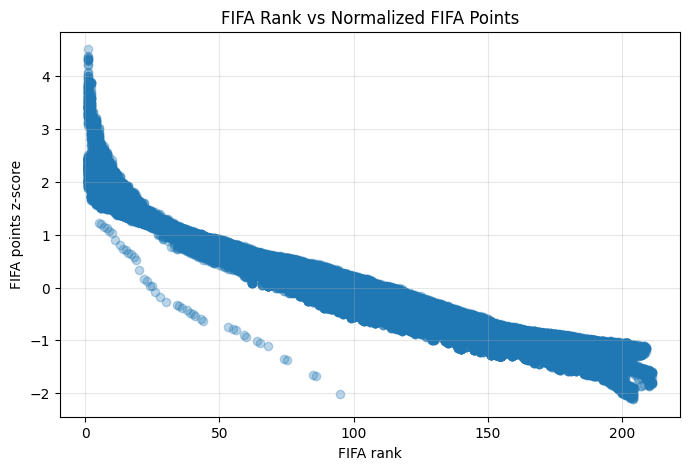

In [204]:
plot_scatter(
    df_fifa,
    "rank",
    "fifa_points_zscore_by_date",
    title="FIFA Rank vs Normalized FIFA Points",
    xlabel="FIFA rank",
    ylabel="FIFA points z-score"
)

Why There Are Still A Few Separated Dots

Some older FIFA ranking dates may have fewer teams or slightly different distributions. But compared with raw total_points, this is much cleaner.

I will flag the separated / unusual FIFA rows by looking for rows where the normalized points don’t match the rank pattern well.

In [205]:
fifa_zscore_outliers = df_fifa[
    (df_fifa["fifa_points_zscore_by_date"] > 4) |
    (df_fifa["fifa_points_zscore_by_date"] < -2)
].copy()

print("FIFA z-score outlier rows:", len(fifa_zscore_outliers))

display(
    fifa_zscore_outliers[
        ["date", "team", "rank", "total_points", "fifa_points_zscore_by_date"]
    ].sort_values("fifa_points_zscore_by_date", ascending=False)
)

FIFA z-score outlier rows: 77


,date,team,rank,total_points,fifa_points_zscore_by_date
39999,2011-06-29,Spain,1,1871.0,4.510443
38545,2010-11-17,Spain,1,1920.0,4.372923
39169,2011-02-02,Spain,1,1887.0,4.354870
38960,2011-01-12,Spain,1,1887.0,4.343632
39584,2011-04-13,Spain,1,1857.0,4.333613
...,...,...,...,...,...
23695,2004-08-04,Montserrat,204,6.0,-2.086036
22880,2004-04-14,Montserrat,203,7.0,-2.094187
23083,2004-05-12,Montserrat,203,6.0,-2.099138
23491,2004-07-07,Montserrat,204,6.0,-2.106911


But for the separated dots specifically, I’d also flag old ranking dates with small team counts:

In [206]:
ranking_date_sizes = (
    df_fifa.groupby("date")
    .size()
    .reset_index(name="teams_in_ranking_date")
)

df_fifa = df_fifa.merge(ranking_date_sizes, on="date", how="left")

In [207]:
small_ranking_dates = df_fifa[
    df_fifa["teams_in_ranking_date"] < 100
].copy()

print("Rows from small FIFA ranking dates:", len(small_ranking_dates))

display(
    small_ranking_dates[
        ["date", "team", "rank", "total_points", "fifa_points_zscore_by_date", "teams_in_ranking_date"]
    ].sort_values(["date", "rank"])
)

Rows from small FIFA ranking dates: 48


,date,team,rank,total_points,fifa_points_zscore_by_date,teams_in_ranking_date
67532,2026-06-11,Argentina,1,1877.27,1.876647,48
67533,2026-06-11,Spain,2,1874.71,1.861276,48
67534,2026-06-11,France,3,1870.70,1.837199,48
67535,2026-06-11,England,4,1828.02,1.580940,48
67536,2026-06-11,Portugal,5,1767.85,1.219667,48
67537,2026-06-11,Brazil,6,1765.86,1.207718,48
67538,2026-06-11,Morocco,7,1755.10,1.143113,48
67539,2026-06-11,Netherlands,8,1753.57,1.133927,48
67540,2026-06-11,Belgium,9,1742.24,1.065899,48
67541,2026-06-11,Germany,10,1735.77,1.027052,48


In [209]:
df_fifa["is_partial_fifa_ranking_date"] = df_fifa["teams_in_ranking_date"] < 100

The 2026-06-11 FIFA ranking date contains only 48 teams, which matches the World Cup 2026 team list. This is not necessarily bad data, but it is a partial ranking snapshot rather than a full FIFA ranking table.

I flagged these rows with `is_partial_fifa_ranking_date` so the model can identify ranking dates that do not contain the full FIFA team universe.

form_score_5  = performance in previous 5 matches

form_score_10 = performance in previous 10 matches

Both are normalized between:
* 0 = worst form
* 1 = perfect form

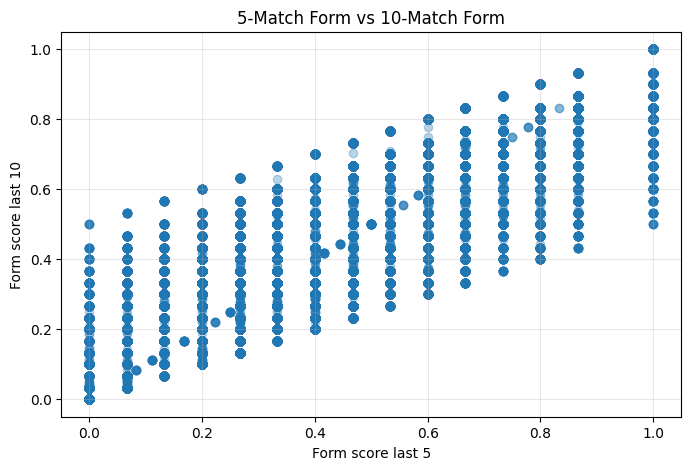

In [210]:
plot_scatter(
    df_form,
    "form_score_5",
    "form_score_10",
    title="5-Match Form vs 10-Match Form",
    xlabel="Form score last 5",
    ylabel="Form score last 10"
)

### Relationship Between 5-Match and 10-Match Form

The scatter plot compares `form_score_5` and `form_score_10`.

Both features are discrete because they are calculated from match points:

- win = 3 points
- draw = 1 point
- loss = 0 points

So:

- `form_score_5 = points_5 / 15`
- `form_score_10 = points_10 / 30`

This is why the plot forms visible vertical and horizontal patterns instead of a smooth cloud.

The upward pattern appears because the last 5 matches are included inside the last 10 matches. Teams with strong last-5 form usually also have strong last-10 form.

The points away from the main pattern are also useful. They show teams whose recent form changed:

- `form_score_5 > form_score_10`: the team has improved recently.
- `form_score_5 < form_score_10`: the team has declined recently.
- `form_score_5 ≈ form_score_10`: the team has stable form.

Because of this, a useful feature to create later is:

`form_trend = form_score_5 - form_score_10`

This captures whether a team is improving or declining compared with its broader recent form.

The below graph is showing 
* goals scored in the previous 5 matches

`vs`

* goals conceded in the previous 5 matches

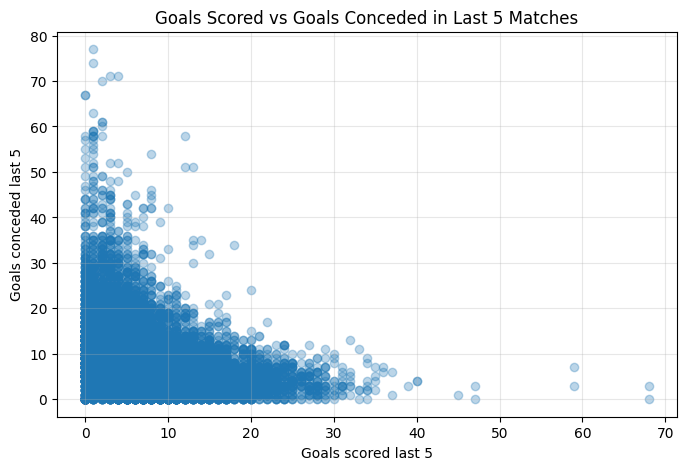

In [211]:
plot_scatter(
    df_form,
    "goals_scored_5",
    "goals_conceded_5",
    title="Goals Scored vs Goals Conceded in Last 5 Matches",
    xlabel="Goals scored last 5",
    ylabel="Goals conceded last 5"
)

This shows:
* average_goals_scored 

vs
* average_goals_conceded

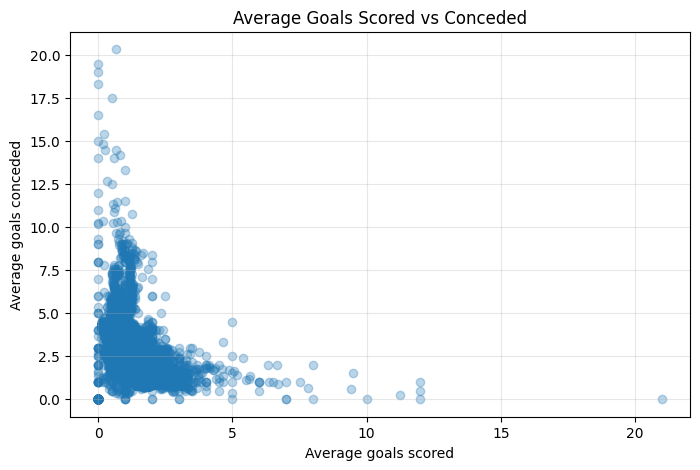

In [213]:
plot_scatter(
    df_goals,
    "average_goals_scored",
    "average_goals_conceded",
    title="Average Goals Scored vs Conceded",
    xlabel="Average goals scored",
    ylabel="Average goals conceded"
)

### Goals Scored vs Goals Conceded

I compared attacking and defensive goal features before modeling.

The recent-form plot shows goals scored and conceded across the previous 5 matches. Most teams are clustered in a normal low-to-moderate range, but there are some extreme outliers caused by very one-sided matches.

The historical-goals plot shows average goals scored and conceded before each match. Most values are around normal football ranges, but a few teams have extreme averages, likely because of small sample sizes or unusual mismatches.

Because of these outliers, raw goal totals should be used carefully. For modeling, capped average goal features are safer than raw cumulative totals or uncapped recent goal totals.

In [215]:
avg_goal_outliers = df_goals[
    (df_goals["average_goals_scored"] > 10) |
    (df_goals["average_goals_conceded"] > 10)
].copy()

print("Rows with average goals scored or conceded over 10:", len(avg_goal_outliers))

display(
    avg_goal_outliers[
        [
            "date",
            "team",
            "opponent",
            "is_home",
            "cumulative_matches",
            "cumulative_goals_scored",
            "cumulative_goals_conceded",
            "average_goals_scored",
            "average_goals_conceded",
        ]
    ].sort_values(
        ["average_goals_scored", "average_goals_conceded"],
        ascending=False
    )
)

Rows with average goals scored or conceded over 10: 36


,date,team,opponent,is_home,cumulative_matches,cumulative_goals_scored,cumulative_goals_conceded,average_goals_scored,average_goals_conceded
74125,2013-06-25,Quebec,Provence,False,1,21,0,21.000,0.000
47340,1999-06-28,Gotland,Shetland,True,1,12,1,12.000,1.000
74130,2013-06-27,Quebec,Kurdistan,True,2,24,1,12.000,0.500
79433,2016-05-31,Western Armenia,Abkhazia,False,1,12,0,12.000,0.000
64272,2008-07-07,Sápmi,Iraqi Kurdistan,True,4,45,1,11.250,0.250
54741,2003-07-03,Kiribati,Solomon Islands,False,4,5,43,1.250,10.750
54685,2003-06-30,Kiribati,Tuvalu,False,3,3,40,1.000,13.333
71777,2012-06-04,Raetia,Zanzibar,False,2,2,23,1.000,11.500
54820,2003-07-07,Kiribati,Vanuatu,True,6,5,62,0.833,10.333
41082,1995-08-21,Cook Islands,Solomon Islands,True,5,4,71,0.800,14.200


In [216]:
teams_avg_over_10 = (
    avg_goal_outliers["team"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Teams with average goals scored/conceded over 10:")
print(teams_avg_over_10)

Teams with average goals scored/conceded over 10:
['Chechnya', 'Cook Islands', 'Darfur', 'Gotland', 'Kiribati', 'Orkney', 'Quebec', 'Raetia', 'Saint Pierre and Miquelon', 'Sark', 'Sápmi', 'Western Armenia']


In [217]:
team_avg_outlier_summary = (
    avg_goal_outliers
    .groupby("team")
    .agg(
        rows=("team", "size"),
        max_avg_goals_scored=("average_goals_scored", "max"),
        max_avg_goals_conceded=("average_goals_conceded", "max"),
        min_cumulative_matches=("cumulative_matches", "min"),
        max_cumulative_matches=("cumulative_matches", "max"),
    )
    .sort_values(
        ["max_avg_goals_scored", "max_avg_goals_conceded"],
        ascending=False
    )
)

display(team_avg_outlier_summary)

,rows,max_avg_goals_scored,max_avg_goals_conceded,min_cumulative_matches,max_cumulative_matches
team,,,,,
Quebec,2,21.000,0.500,1,2
Gotland,1,12.000,1.000,1,1
Western Armenia,1,12.000,0.000,1,1
Sápmi,1,11.250,0.250,4,4
Kiribati,7,1.250,13.333,3,10
Raetia,1,1.000,11.500,2,2
Cook Islands,8,0.800,20.333,3,10
Darfur,6,0.333,16.500,1,6
Saint Pierre and Miquelon,4,0.167,11.000,1,6


In [218]:
df_goals["has_enough_goal_history"] = df_goals["cumulative_matches"] >= 10

df_goals["average_goals_scored_capped"] = df_goals["average_goals_scored"].clip(upper=6)
df_goals["average_goals_conceded_capped"] = df_goals["average_goals_conceded"].clip(upper=6)

### Goal Average Outliers

I checked teams with average goals scored or conceded above 10. These extreme values mostly come from teams with very few previous matches, where one unusual result can heavily distort the average.

For example, Quebec has a very high average goals scored because it had only one or two previous matches in the dataset. Other teams, such as Cook Islands, Kiribati, Sark, and Darfur, have extreme average goals conceded because of very heavy defeats in small or regional competitions.

These rows are not necessarily data errors, but they are unstable estimates. To reduce their influence, I will use capped average-goal features and add a flag for whether the team has enough historical match data.

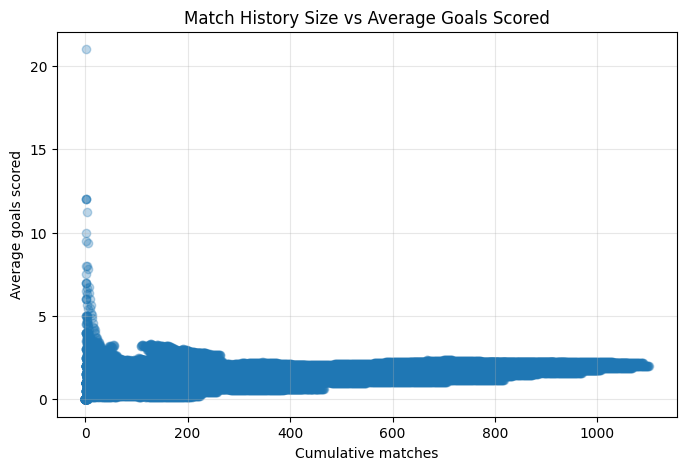

In [214]:
plot_scatter(
    df_goals,
    "cumulative_matches",
    "average_goals_scored",
    title="Match History Size vs Average Goals Scored",
    xlabel="Cumulative matches",
    ylabel="Average goals scored"
)

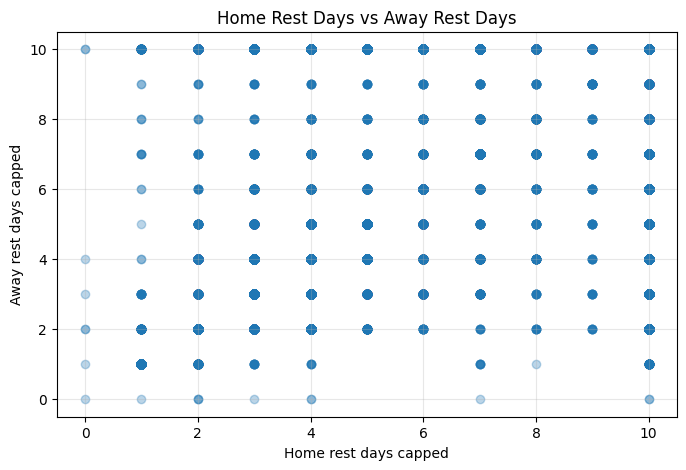

In [212]:
plot_scatter(
    df_rest,
    "home_rest_days_capped",
    "away_rest_days_capped",
    title="Home Rest Days vs Away Rest Days",
    xlabel="Home rest days capped",
    ylabel="Away rest days capped"
)

### Home vs Away Rest Days

This plot compares capped rest days for the home and away teams. Because rest days are capped at 10, the values form a grid between 0 and 10.

The diagonal pattern shows that many matches have equal rest for both teams. Matches away from the diagonal represent a rest advantage for one side.

This supports using `rest_days_diff` as a compact feature, since it directly captures whether the home or away team had more recovery time.

### For df_home and df_stage, scatter plots are not very useful because they are mostly categorical/boolean.

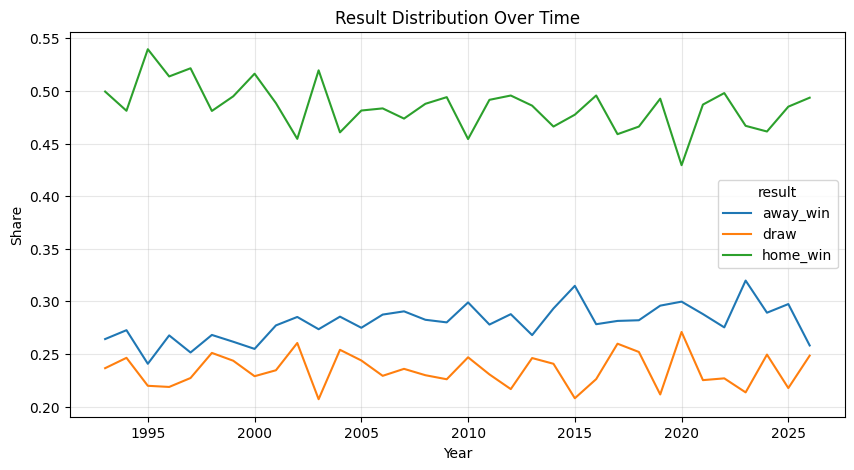

In [222]:
result_by_year = (
    df_res
    .groupby([df_res["date"].dt.year, "result"])
    .size()
    .unstack(fill_value=0)
)

result_share_by_year = result_by_year.div(result_by_year.sum(axis=1), axis=0)

result_share_by_year.plot(figsize=(10, 5))
plt.title("Result Distribution Over Time")
plt.xlabel("Year")
plt.ylabel("Share")
plt.grid(alpha=0.3)
plt.show()

### Result Distribution Over Time

The result distribution is fairly stable across years. Home wins are consistently the most common outcome, followed by away wins and then draws.

This confirms that the class imbalance is not caused by one unusual period; it is a natural pattern in international football. Because of this, model evaluation should not rely only on accuracy. The model should be compared against a baseline that always predicts the most common class, and probability-based metrics such as log loss should also be used.

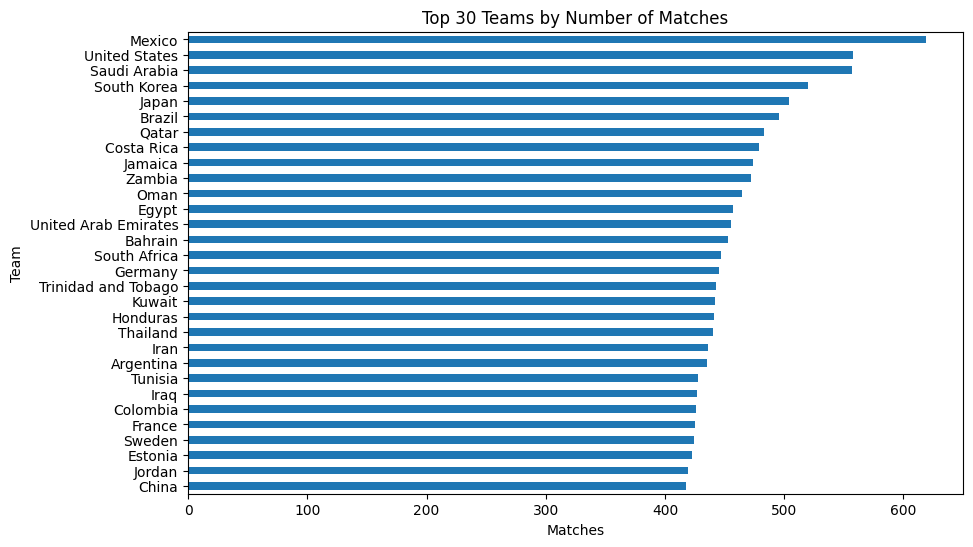

In [223]:
team_match_counts = pd.concat([
    df_res["home_team"],
    df_res["away_team"]
]).value_counts().head(30)

plt.figure(figsize=(10, 6))
team_match_counts.sort_values().plot(kind="barh")
plt.title("Top 30 Teams by Number of Matches")
plt.xlabel("Matches")
plt.ylabel("Team")
plt.show()

### Team Match Count Distribution

I checked how often each team appears in the historical results dataset by combining home and away matches.

Some teams appear much more often than others, which is expected because major national teams and teams from active confederations play more international matches. This creates more reliable historical features for those teams.

The model may perform better for teams with many historical matches and be less reliable for teams with limited match history. This supports keeping history-size features or reliability flags, such as `cumulative_matches` or `has_enough_goal_history`, when building the final training table.

Why useful: friendlies and World Cup matches are not the same intensity. You may eventually add tournament or match importance.

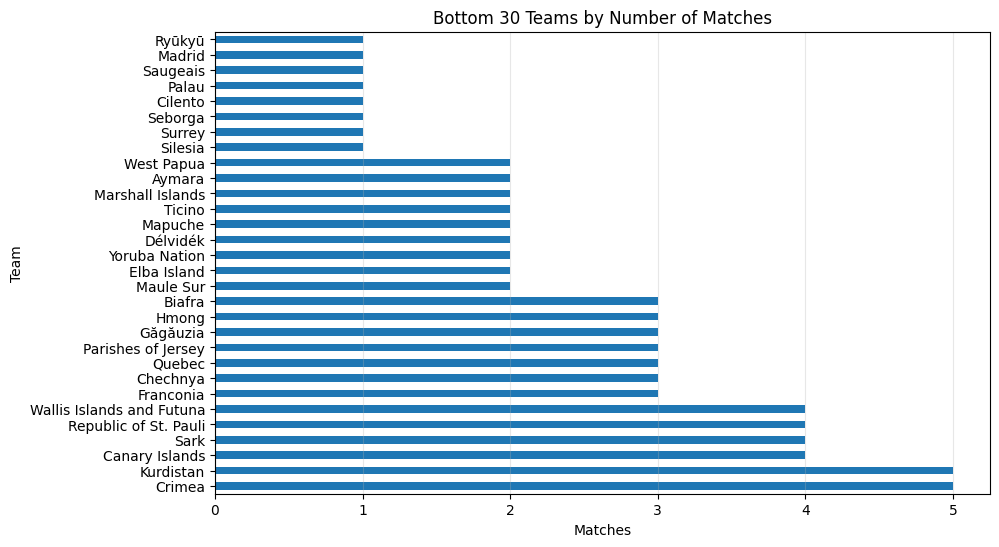

In [232]:
team_match_counts = pd.concat([
    df_res["home_team"],
    df_res["away_team"]
]).value_counts()

lowest_team_match_counts = team_match_counts.sort_values().head(30)

plt.figure(figsize=(10, 6))
lowest_team_match_counts.sort_values(ascending=False).plot(kind="barh")
plt.title("Bottom 30 Teams by Number of Matches")
plt.xlabel("Matches")
plt.ylabel("Team")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [233]:
display(
    lowest_team_match_counts
    .rename_axis("team")
    .reset_index(name="matches")
)

,team,matches
0,Ryūkyū,1
1,Silesia,1
2,Madrid,1
3,Saugeais,1
4,Palau,1
5,Cilento,1
6,Seborga,1
7,Surrey,1
8,West Papua,2
9,Aymara,2


In [234]:
low_history_teams = team_match_counts[team_match_counts < 10]

print("Teams with fewer than 10 matches:", len(low_history_teams))

display(
    low_history_teams
    .sort_values()
    .rename_axis("team")
    .reset_index(name="matches")
)

Teams with fewer than 10 matches: 55


,team,matches
0,Ryūkyū,1
1,Silesia,1
2,Madrid,1
3,Saugeais,1
4,Palau,1
5,Cilento,1
6,Surrey,1
7,Seborga,1
8,Aymara,2
9,Ticino,2


### Low-History Teams

I checked the teams with the fewest matches in the historical results dataset. Several teams have fewer than 10 recorded matches, including regional, non-FIFA, or historical teams.

These rows are not necessarily data errors, but they can create unstable features. For example, a team with only one or two matches can have an extreme average goals scored or conceded value.

To avoid overtrusting these small-sample statistics, I flag teams with fewer than 10 matches as low-history teams. These rows can either be kept with reliability flags or removed in a stricter modeling experiment.

In [235]:
team_match_counts = pd.concat([
    df_res["home_team"],
    df_res["away_team"]
]).value_counts()

LOW_HISTORY_THRESHOLD = 10

low_history_teams = set(
    team_match_counts[team_match_counts < LOW_HISTORY_THRESHOLD].index
)

df_res["home_low_history_team"] = df_res["home_team"].isin(low_history_teams)
df_res["away_low_history_team"] = df_res["away_team"].isin(low_history_teams)

In [236]:
low_history_matches = df_res[
    df_res["home_low_history_team"] | df_res["away_low_history_team"]
]

print("Matches involving low-history teams:", len(low_history_matches))
print("Share:", len(low_history_matches) / len(df_res))

Matches involving low-history teams: 227
Share: 0.007395100338806359


Only 227 matches involve low-history teams, which is about 0.74% of the historical results dataset. Because this is a very small share, I will keep these matches for now rather than remove them.

However, I flag low-history teams so the model can identify rows where team-level statistics may be less reliable. Later, I can compare model performance with and without these rows as a robustness check.

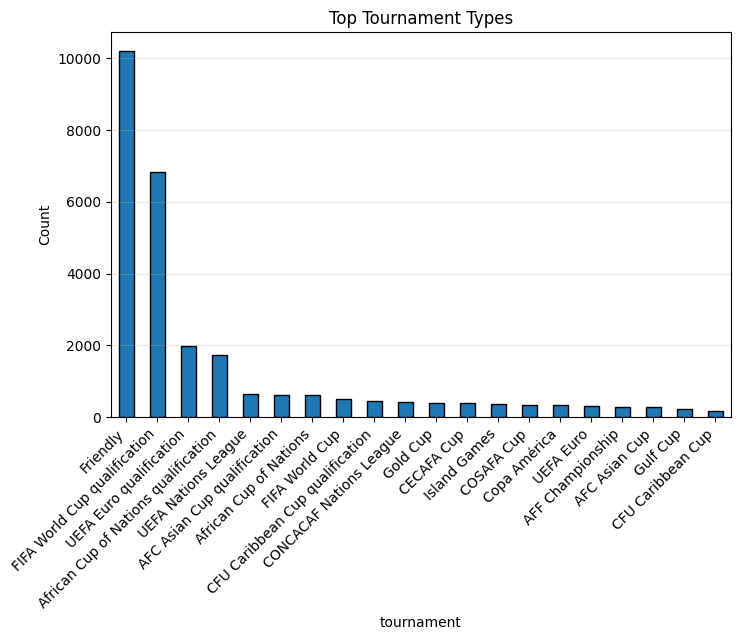

In [224]:
plot_bar_counts(
    df_res,
    "tournament",
    title="Top Tournament Types",
    top_n=20
)

In [238]:
def match_importance(tournament):
    tournament = str(tournament).lower()

    if tournament == "friendly":
        return "friendly"

    if "fifa world cup" in tournament and "qualification" not in tournament:
        return "world_cup"

    if any(x in tournament for x in [
        "uefa euro",
        "copa america",
        "african cup of nations",
        "afc asian cup",
        "gold cup",
        "ofc nations cup",
        "concacaf championship",
        "uefa nations league",
        "concacaf nations league",
        "caf nations championship",
    ]):
        return "major_competition"

    if "qualification" in tournament:
        return "qualification"

    return "other"

In [239]:
df_res["match_importance"] = df_res["tournament"].apply(match_importance)

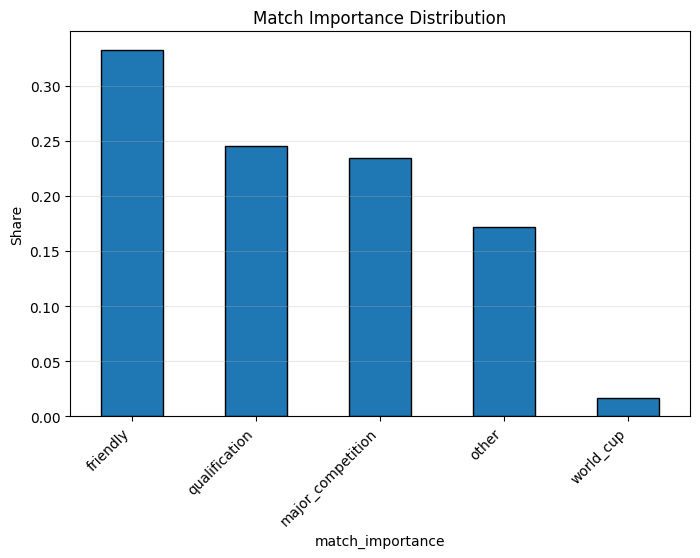

In [240]:
plot_bar_counts(
    df_res,
    "match_importance",
    title="Match Importance Distribution",
    normalize=True
)

### Match Importance

Tournament type can affect match intensity. A friendly is not the same as a World Cup match or a continental championship.

Instead of using a very simple tournament grouping, I create a `match_importance` feature. This separates matches into friendlies, qualification matches, major competitions, World Cup matches and other tournaments.

This gives the model a better signal about how competitive or important each match is likely to be.

Why useful: partial ranking dates can affect merges and normalized points.

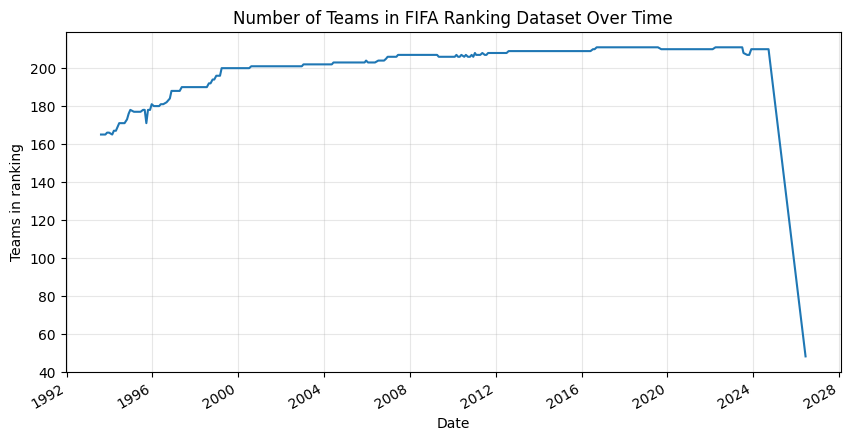

In [225]:
fifa_teams_per_date = df_fifa.groupby("date")["team"].nunique()

plt.figure(figsize=(10, 5))
fifa_teams_per_date.plot()
plt.title("Number of Teams in FIFA Ranking Dataset Over Time")
plt.xlabel("Date")
plt.ylabel("Teams in ranking")
plt.grid(alpha=0.3)
plt.show()

Train model on historical matches up to before 2026.

Use latest 2026 FIFA ranking snapshot when building WC 2026 prediction rows.

In [242]:
wc_2026_fixtures = pd.read_csv(
    os.path.join(datasets_dir, "WC 2026 fixtures.csv")
)

wc_2026_fixtures["date"] = pd.to_datetime(wc_2026_fixtures["date"])

df_predict = wc_2026_fixtures.copy()

In [243]:
df_train = df_merged[df_merged["date"] < "2026-01-01"].copy()
df_predict = wc_2026_fixtures.copy()

In [244]:
latest_fifa = (
    df_fifa[df_fifa["date"] <= "2026-06-11"]
    .sort_values("date")
    .groupby("team")
    .tail(1)
)

The 2026 FIFA ranking snapshot is important for prediction because it represents the latest team strength before the World Cup. However, it should be used as prediction input, not as training data.

The model should be trained on historical matches with known outcomes. Then, when predicting the 2026 World Cup, the latest available FIFA rankings can be joined to the 2026 fixtures as current team-strength features.

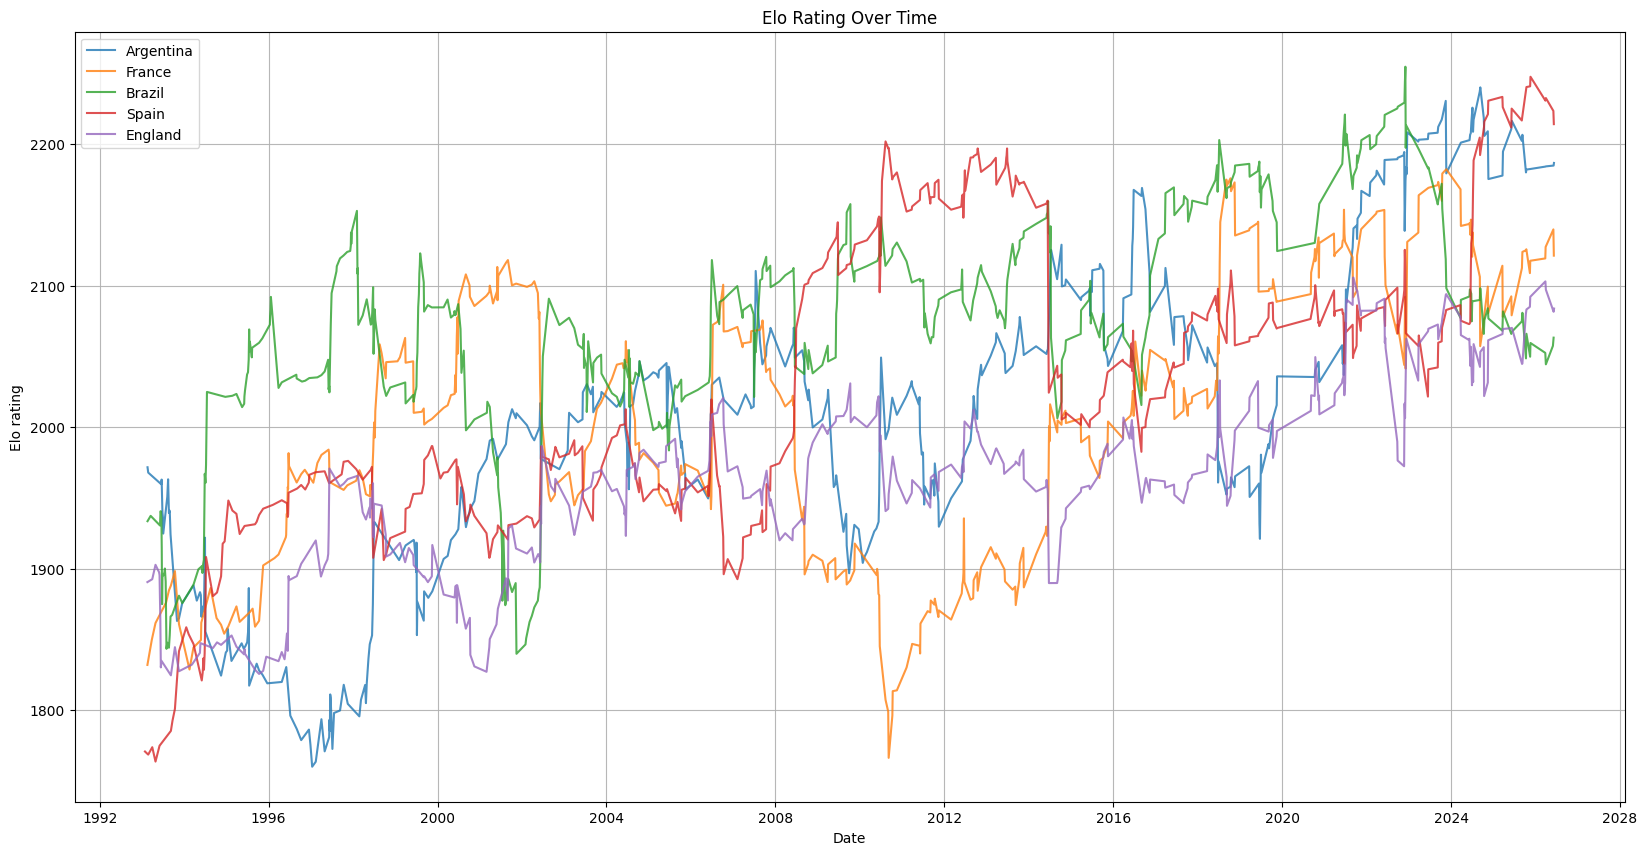

In [230]:
teams = ["Argentina", "France", "Brazil", "Spain", "England"]

plt.figure(figsize=(20, 10))

for team in teams:
    team_elo = df_elo[df_elo["team"] == team].sort_values("date")
    plt.plot(team_elo["date"], team_elo["elo_rating"], label=team, alpha=0.8)

plt.title("Elo Rating Over Time")
plt.xlabel("Date")
plt.ylabel("Elo rating")
plt.legend()
plt.grid(alpha=0.9)
plt.show()

### Elo Rating Over Time

I plotted Elo ratings over time for several major national teams as a sanity check.

The ratings move within a realistic range for strong teams and reflect known performance cycles. For example, Spain rises strongly around its 2008-2012 peak, and Argentina rises in the modern period.

This suggests that Elo is behaving as a useful dynamic team-strength feature. Because it updates over time based on match results, it should be one of the strongest predictors in the final model.

# training leakage